# Credit Risk Prediction — End-to-End Pipeline
**Project:** VIX IDX Partners — Data Scientist Intern  
**Dataset:** `loan_data_2007_2014.csv` (466K+ records, 74 features)  
**Tujuan:** Membangun model ML untuk memprediksi risiko gagal bayar pinjaman

---

## Workflow Pipeline
| Stage | Deskripsi |
|---|---|
| 1 | EDA Awal — Load data, info, statistik deskriptif |
| 2 | EDA Visualisasi — Histogram, heatmap, boxplot |
| 3 | Preprocessing — Binarisasi, drop kolom, encoding |
| 4 | Split & SMOTE — Train/test, oversampling, scaling |
| 5 | Modeling — LR, DT, RF, XGBoost |
| 6 | Tuning — Hyperparameter optimization & Feature Importance |


---
# Stage 1
---

## Import Library

Pada tahap ini kita mengimpor library **pandas** yang akan digunakan untuk manipulasi dan analisis data. Kita juga mengatur beberapa display option agar output tabel lebih mudah dibaca, termasuk menampilkan semua kolom dan mengatur lebar tampilan.

In [101]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 40)

## Step 1 — Load Dataset & Tampilkan 5 Baris Pertama

Dataset `loan_data_2007_2014.csv` berisi data pinjaman dari tahun 2007 hingga 2014. Parameter `index_col=0` digunakan untuk menjadikan kolom pertama (unnamed index) sebagai index dataframe, sedangkan `low_memory=False` menghindari warning tipe data campuran pada kolom tertentu. Menampilkan 5 baris pertama penting untuk mendapatkan gambaran awal tentang struktur dan isi data.

In [102]:
df = pd.read_csv('data/loan_data_2007_2014.csv', index_col=0, low_memory=False)
print(f"Dataset berhasil di-load dengan {df.shape[0]:,} baris dan {df.shape[1]} kolom.")
df.head()

Dataset berhasil di-load dengan 466,285 baris dan 74 kolom.


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/l...,Borrower added on 12/22/11 > I nee...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/l...,Borrower added on 12/22/11 > I pla...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/l...,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/l...,Borrower added on 12/21/11 > to pa...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/l...,Borrower added on 12/21/11 > I pla...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2 — Informasi Dataset: Shape, Tipe Data, & Missing Values

Langkah ini sangat krusial untuk memahami kualitas data. Kita perlu mengetahui berapa jumlah baris dan kolom, tipe data setiap kolom (numerik vs kategorikal), serta berapa banyak nilai yang hilang (missing values) per kolom. Informasi ini akan menjadi dasar keputusan preprocessing, seperti apakah suatu kolom perlu di-drop, di-imputasi, atau di-encode.

In [103]:
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print()

info_df = pd.DataFrame({
    'Tipe Data': df.dtypes,
    'Jumlah Missing': df.isnull().sum(),
    'Persentase Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
info_df

Jumlah baris  : 466,285
Jumlah kolom  : 74



,Tipe Data,Jumlah Missing,Persentase Missing (%)
id,int64,0,0.00
member_id,int64,0,0.00
loan_amnt,int64,0,0.00
funded_amnt,int64,0,0.00
funded_amnt_inv,float64,0,0.00
...,...,...,...
all_util,float64,466285,100.00
total_rev_hi_lim,float64,70276,15.07
inq_fi,float64,466285,100.00
total_cu_tl,float64,466285,100.00


## Step 3 — Statistik Deskriptif (Kolom Numerik)

Fungsi `describe()` memberikan ringkasan statistik untuk semua kolom numerik, termasuk count, mean, standard deviation, min, max, dan kuartil (25%, 50%, 75%). Dengan men-transpose hasilnya (`.T`), kita bisa lebih mudah membandingkan skala dan distribusi antar kolom. Perhatikan juga apakah ada kolom dengan range nilai yang sangat besar (indikasi outlier) atau kolom dengan count yang jauh lebih kecil dari total baris (indikasi missing values).

In [104]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01
delinq_2yrs,466256.0,2.846784e-01,7.973651e-01,0.00,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01


## Step 4 — Distribusi Kolom Target: `loan_status`

Kolom `loan_status` adalah target variable yang akan kita prediksi. Memahami distribusi kelas sangat penting karena akan mempengaruhi strategi pemodelan. Jika distribusi sangat tidak seimbang (imbalanced), kita perlu menerapkan teknik seperti oversampling, undersampling, atau class weighting. Dataset ini memiliki 9 kategori unik yang nantinya perlu di-mapping menjadi binary classification (Good Loan vs Bad Loan).

In [105]:
target_dist = pd.DataFrame({
    'Jumlah': df['loan_status'].value_counts(),
    'Persentase (%)': (df['loan_status'].value_counts(normalize=True) * 100).round(2)
})
print(f"Jumlah kategori unik: {df['loan_status'].nunique()}")
target_dist

Jumlah kategori unik: 9


,Jumlah,Persentase (%)
loan_status,,
Current,224226,48.09
Fully Paid,184739,39.62
Charged Off,42475,9.11
Late (31-120 days),6900,1.48
In Grace Period,3146,0.67
Does not meet the credit policy. Status:Fully Paid,1988,0.43
Late (16-30 days),1218,0.26
Default,832,0.18
Does not meet the credit policy. Status:Charged Off,761,0.16


## Step 5 — Ringkasan Awal & Rekomendasi

Berdasarkan eksplorasi di atas, berikut adalah ringkasan temuan utama dan rekomendasi untuk tahap preprocessing selanjutnya. Kita akan mengidentifikasi 5 kategori kolom yang memerlukan penanganan khusus:

1. **Kolom 100% missing** — seluruh nilai kosong, wajib di-drop
2. **Kolom identitas/teks bebas** — tidak memberikan informasi prediktif
3. **Kolom zero variance** — hanya punya 1 nilai unik, tidak berguna
4. **Kolom missing >50%** — pertimbangkan drop atau imputasi
5. **Kolom data leakage** — informasi yang hanya tersedia setelah pinjaman diberikan

### 5a. Kolom 100% Missing

Kolom-kolom ini memiliki seluruh nilai NaN sehingga sama sekali tidak memberikan informasi apapun. Kolom-kolom ini **wajib di-drop** tanpa pengecualian karena tidak ada data yang bisa dimanfaatkan.

In [106]:
cols_all_missing = df.columns[df.isnull().sum() == len(df)].tolist()
print(f"Jumlah kolom 100% missing: {len(cols_all_missing)}")
for c in cols_all_missing:
    print(f"  - {c}")

Jumlah kolom 100% missing: 17
  - annual_inc_joint
  - dti_joint
  - verification_status_joint
  - open_acc_6m
  - open_il_6m
  - open_il_12m
  - open_il_24m
  - mths_since_rcnt_il
  - total_bal_il
  - il_util
  - open_rv_12m
  - open_rv_24m
  - max_bal_bc
  - all_util
  - inq_fi
  - total_cu_tl
  - inq_last_12m


### 5b. Kolom Identitas / URL / Teks Bebas

Kolom seperti `id`, `member_id`, `url`, `desc`, `emp_title`, `title`, dan `zip_code` merupakan kolom identitas atau teks bebas yang **tidak relevan** untuk model prediktif. Kolom `id` dan `member_id` hanyalah identifier unik. Kolom `url` mengarah ke halaman web. Kolom `desc` dan `emp_title` berisi teks tidak terstruktur dengan kardinalitas sangat tinggi.

In [107]:
cols_irrelevant = ['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code']
print("Kolom identitas/teks bebas (tidak relevan untuk model):")
for c in cols_irrelevant:
    miss = df[c].isnull().sum()
    pct = round(miss / len(df) * 100, 2)
    nuniq = df[c].nunique()
    print(f"  - {c:25s} | Missing: {miss:>7,} ({pct}%) | Unique: {nuniq:,}")

Kolom identitas/teks bebas (tidak relevan untuk model):
  - id                        | Missing:       0 (0.0%) | Unique: 466,285
  - member_id                 | Missing:       0 (0.0%) | Unique: 466,285
  - url                       | Missing:       0 (0.0%) | Unique: 466,285
  - desc                      | Missing: 340,304 (72.98%) | Unique: 124,435
  - emp_title                 | Missing:  27,588 (5.92%) | Unique: 205,475
  - title                     | Missing:      21 (0.0%) | Unique: 63,098
  - zip_code                  | Missing:       0 (0.0%) | Unique: 888


### 5c. Kolom Zero Variance (Hanya 1 Nilai Unik)

Kolom dengan hanya 1 nilai unik tidak memiliki variasi apapun (zero variance) sehingga tidak bisa memberikan daya pembeda dalam model. Kolom seperti ini **wajib di-drop** karena secara statistik tidak berkontribusi pada prediksi.

In [108]:
cols_single = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print(f"Jumlah kolom zero variance: {len(cols_single)}")
for c in cols_single:
    unique_val = df[c].dropna().unique()
    print(f"  - {c:25s} | Nilai: {unique_val}")

Jumlah kolom zero variance: 19
  - policy_code               | Nilai: [1]
  - application_type          | Nilai: ['INDIVIDUAL']
  - annual_inc_joint          | Nilai: []
  - dti_joint                 | Nilai: []
  - verification_status_joint | Nilai: []
  - open_acc_6m               | Nilai: []
  - open_il_6m                | Nilai: []
  - open_il_12m               | Nilai: []
  - open_il_24m               | Nilai: []
  - mths_since_rcnt_il        | Nilai: []
  - total_bal_il              | Nilai: []
  - il_util                   | Nilai: []
  - open_rv_12m               | Nilai: []
  - open_rv_24m               | Nilai: []
  - max_bal_bc                | Nilai: []
  - all_util                  | Nilai: []
  - inq_fi                    | Nilai: []
  - total_cu_tl               | Nilai: []
  - inq_last_12m              | Nilai: []


### 5d. Kolom Missing >50%

Kolom-kolom dengan persentase missing values di atas 50% perlu dipertimbangkan secara hati-hati. Secara umum, imputasi pada kolom dengan missing sangat tinggi bisa memperkenalkan bias yang besar. Opsi terbaik biasanya adalah **drop kolom** ini, kecuali ada alasan bisnis yang kuat untuk mempertahankannya.

In [109]:
cols_high_missing = [c for c in df.columns
                     if 0 < df[c].isnull().sum() / len(df) < 1
                     and df[c].isnull().sum() / len(df) > 0.50]
print(f"Jumlah kolom missing >50%: {len(cols_high_missing)}")
for c in cols_high_missing:
    pct = round(df[c].isnull().sum() / len(df) * 100, 2)
    print(f"  - {c:35s} | Missing: {pct}%")

Jumlah kolom missing >50%: 4
  - desc                                | Missing: 72.98%
  - mths_since_last_delinq              | Missing: 53.69%
  - mths_since_last_record              | Missing: 86.57%
  - mths_since_last_major_derog         | Missing: 78.77%


### 5e. Kolom Potensial Data Leakage

Data leakage terjadi ketika model dilatih menggunakan informasi yang **tidak tersedia pada saat prediksi** di dunia nyata. Kolom-kolom seperti `total_pymnt`, `recoveries`, `last_pymnt_amnt`, dan sejenisnya berisi informasi yang hanya ada setelah pinjaman sudah berjalan atau selesai. Menggunakan kolom ini akan membuat model terlihat sangat akurat saat training, tetapi gagal total di production. Kolom-kolom ini **wajib di-drop** sebelum pemodelan.

In [110]:
cols_leakage = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'funded_amnt', 'funded_amnt_inv'
]
print(f"Jumlah kolom potensial leakage: {len(cols_leakage)}")
for c in cols_leakage:
    if c in df.columns:
        print(f"  - {c}")

Jumlah kolom potensial leakage: 15
  - out_prncp
  - out_prncp_inv
  - total_pymnt
  - total_pymnt_inv
  - total_rec_prncp
  - total_rec_int
  - total_rec_late_fee
  - recoveries
  - collection_recovery_fee
  - last_pymnt_d
  - last_pymnt_amnt
  - next_pymnt_d
  - last_credit_pull_d
  - funded_amnt
  - funded_amnt_inv


### 5f. Ringkasan Target Variable & Rencana Mapping

Kolom `loan_status` saat ini memiliki **9 kategori** yang perlu disederhanakan menjadi binary classification. Berikut adalah rencana mapping yang umum digunakan pada credit risk modeling:

| Kategori Asli | Label Baru |
|---|---|
| Fully Paid | Good Loan (0) |
| Current | Good Loan (0) |
| Charged Off | Bad Loan (1) |
| Default | Bad Loan (1) |
| Late (31-120 days) | Bad Loan (1) |
| Late (16-30 days) | Bad Loan (1) |
| In Grace Period | Bad Loan (1) |
| Does not meet...Fully Paid | Pertimbangkan |
| Does not meet...Charged Off | Pertimbangkan |

> **Catatan:** Kategori 'Current' bisa juga di-drop karena pinjaman masih berjalan dan hasilnya belum diketahui.

In [111]:
print("Distribusi target variable:")
print(df['loan_status'].value_counts())
print()
print(f"Total kategori unik: {df['loan_status'].nunique()}")
print("\nRencana mapping untuk binary classification:")
print("  GOOD LOAN (0) : 'Fully Paid', 'Current'")
print("  BAD LOAN  (1) : 'Charged Off', 'Default', 'Late (31-120 days)',")
print("                  'Late (16-30 days)', 'In Grace Period'")
print("  REVIEW        : 'Does not meet...' — pertimbangkan dimasukkan/dibuang")

Distribusi target variable:
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Total kategori unik: 9

Rencana mapping untuk binary classification:
  GOOD LOAN (0) : 'Fully Paid', 'Current'
  BAD LOAN  (1) : 'Charged Off', 'Default', 'Late (31-120 days)',
                  'Late (16-30 days)', 'In Grace Period'
  REVIEW        : 'Does not meet...' — pertimbangkan dimasukkan/dibuang


---

## Kesimpulan Stage 1 EDA

Dari eksplorasi awal ini, beberapa kesimpulan penting:

1. **Dataset sangat besar** — 466,285 baris × 74 kolom
2. **Banyak kolom perlu di-drop** — ~30+ kolom (100% missing, zero variance, identitas, leakage)
3. **Target variable perlu di-mapping** — dari 9 kategori menjadi binary (Good/Bad Loan)
4. **Class imbalance terindikasi** — mayoritas data adalah 'Current' (48%) dan 'Fully Paid' (40%)
5. **Beberapa kolom kategorikal** perlu encoding (`grade`, `sub_grade`, `home_ownership`, `term`, dll)

**Langkah selanjutnya:** Stage 2 — Data Cleaning & Preprocessing


---
# Stage 2
---

## Import Library & Load Data
Mengimpor pandas, numpy, matplotlib, dan seaborn untuk analisis dan visualisasi data. 
Dataset di-load dengan `low_memory=False` untuk menghindari warning tipe data campuran pada kolom tertentu. 
Kita juga menyiapkan folder `images/` untuk menyimpan semua visualisasi yang dihasilkan.

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SAVE_DIR = 'images'
for d in ['data','images','models']:
    os.makedirs(d, exist_ok=True)

df = pd.read_csv('data/loan_data_2007_2014.csv', index_col=0, low_memory=False)
print(f'Dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom')

Dataset: 466,285 baris x 74 kolom


## Step 1 — Distribusi Target Variable `loan_status`
Visualisasi countplot dan pie chart untuk memahami sebaran kelas target. 
Distribusi yang tidak seimbang akan mempengaruhi strategi pemodelan — mungkin perlu teknik oversampling/undersampling.

**Insight:** Mayoritas pinjaman berstatus **Current** (48%) dan **Fully Paid** (40%), 
sementara kelas gagal bayar (Charged Off, Default, Late) hanya sekitar 11%. 
Ini menunjukkan dataset sangat **imbalanced** dan perlu penanganan khusus saat modeling.

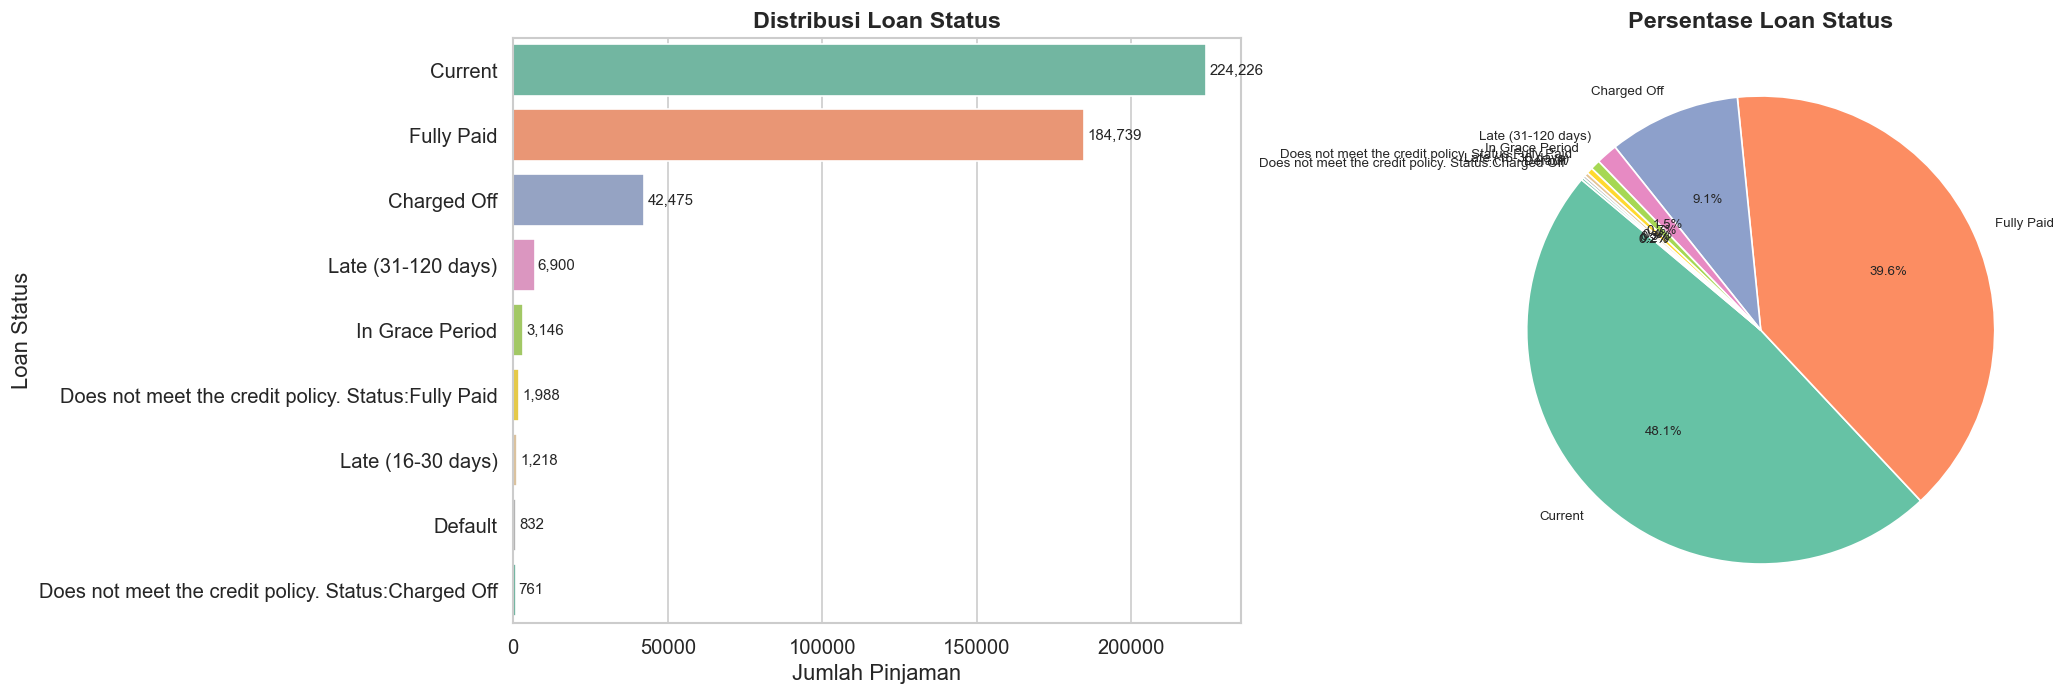

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

order = df['loan_status'].value_counts().index
colors = sns.color_palette('Set2', n_colors=len(order))

sns.countplot(y='loan_status', data=df, order=order, palette=colors, ax=axes[0])
axes[0].set_title('Distribusi Loan Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Pinjaman')
axes[0].set_ylabel('Loan Status')
for i, v in enumerate(df['loan_status'].value_counts()):
    axes[0].text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

pct = df['loan_status'].value_counts()
axes[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 8})
axes[1].set_title('Persentase Loan Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_target_distribution.png')
plt.show()

## Step 2 — Histogram Kolom Numerik Penting
Histogram menunjukkan distribusi frekuensi dari 5 kolom numerik utama: `loan_amnt`, `int_rate`, `annual_inc`, `dti`, dan `installment`. 
Garis merah menunjukkan **mean** dan hijau menunjukkan **median**. Jika mean jauh dari median, ini mengindikasikan distribusi yang skewed.

**Insight:** Kolom `annual_inc` memiliki distribusi **right-skewed** yang sangat kuat (mean >> median), 
menunjukkan adanya outlier pendapatan sangat tinggi. Kolom `loan_amnt` cenderung terkonsentrasi pada kelipatan 5000. 
Kolom `dti` (debt-to-income ratio) mayoritas berada di rentang 10-25%.

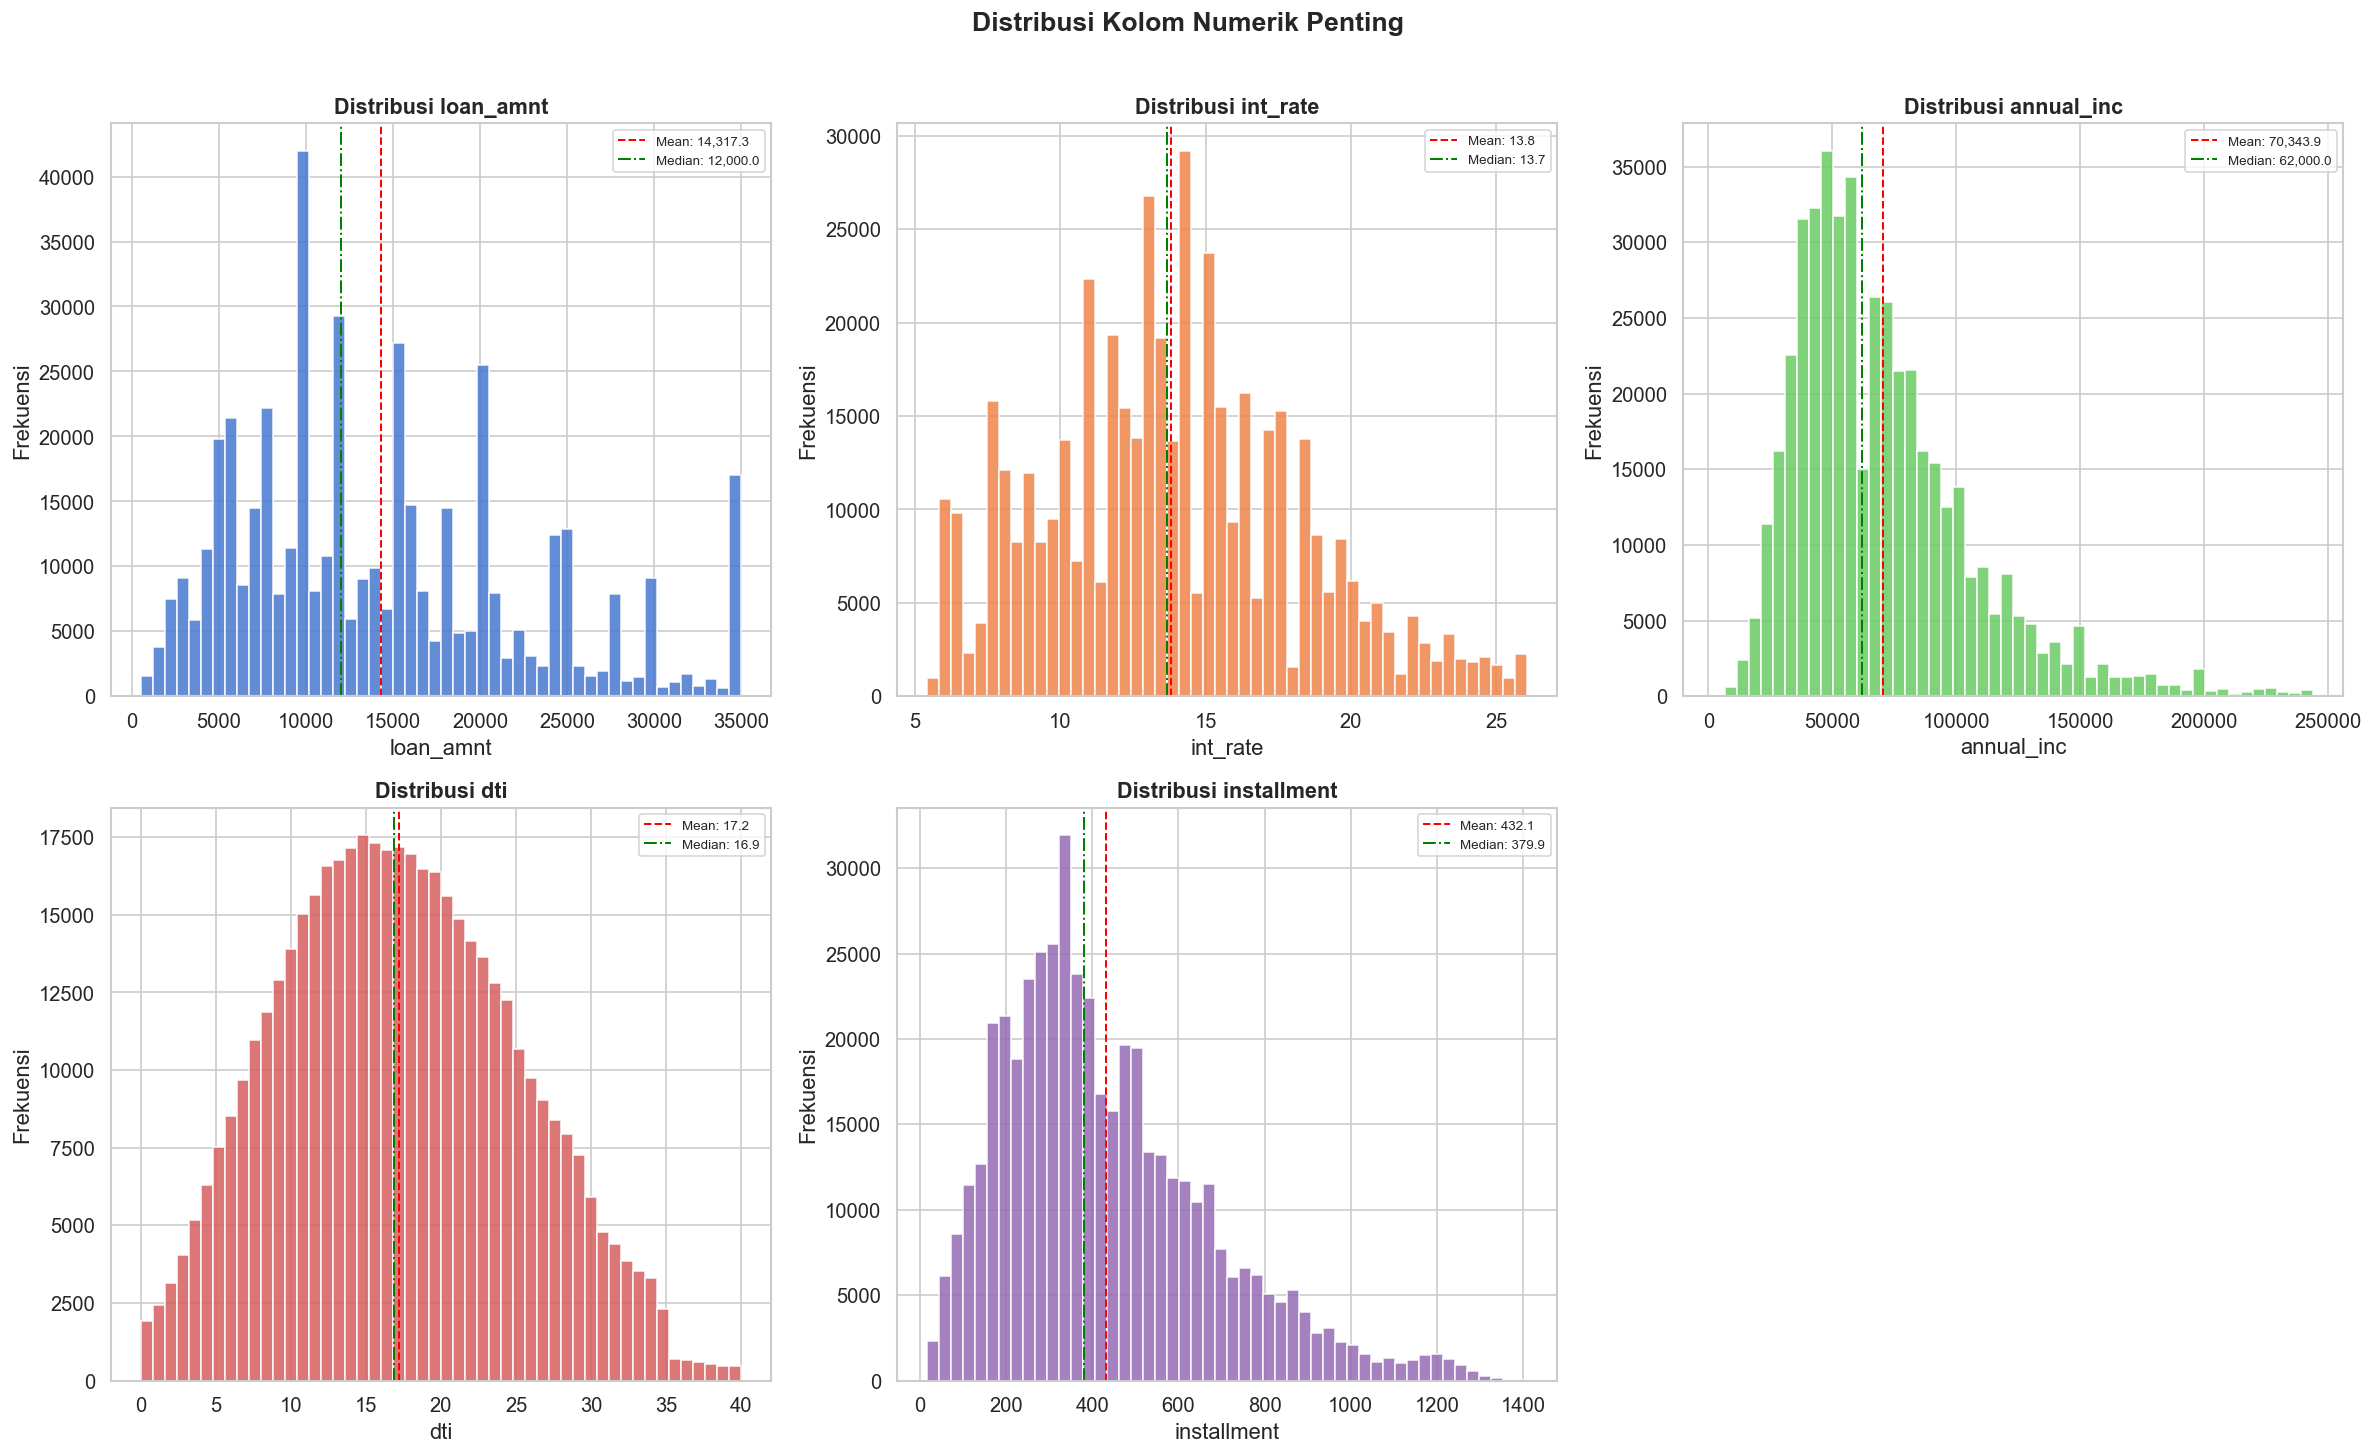

In [114]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    if col == 'annual_inc':
        data = data[data <= data.quantile(0.99)]
    axes[i].hist(data, bins=50, color=sns.color_palette('muted')[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(data.mean(), color='red', linestyle='--', lw=1.2,
                    label=f'Mean: {data.mean():,.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='-.', lw=1.2,
                    label=f'Median: {data.median():,.1f}')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distribusi Kolom Numerik Penting', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_numeric_histograms.png')
plt.show()

## Step 3 — Heatmap Korelasi Antar Kolom Numerik
Heatmap korelasi membantu mengidentifikasi hubungan linear antar fitur numerik. 
Kolom ID dan kolom leakage (post-loan) sudah dikeluarkan agar analisis fokus pada fitur yang relevan. 
Korelasi tinggi antar fitur (multikolinearitas) perlu diperhatikan karena bisa mempengaruhi performa model.

**Insight:** Terdapat korelasi sangat tinggi antara `loan_amnt` - `funded_amnt` - `installment` (r > 0.9). 
Kolom `tot_cur_bal` dan `total_rev_hi_lim` juga berkorelasi cukup tinggi. 
Fitur-fitur yang redundan ini sebaiknya di-drop salah satu untuk menghindari multikolinearitas.

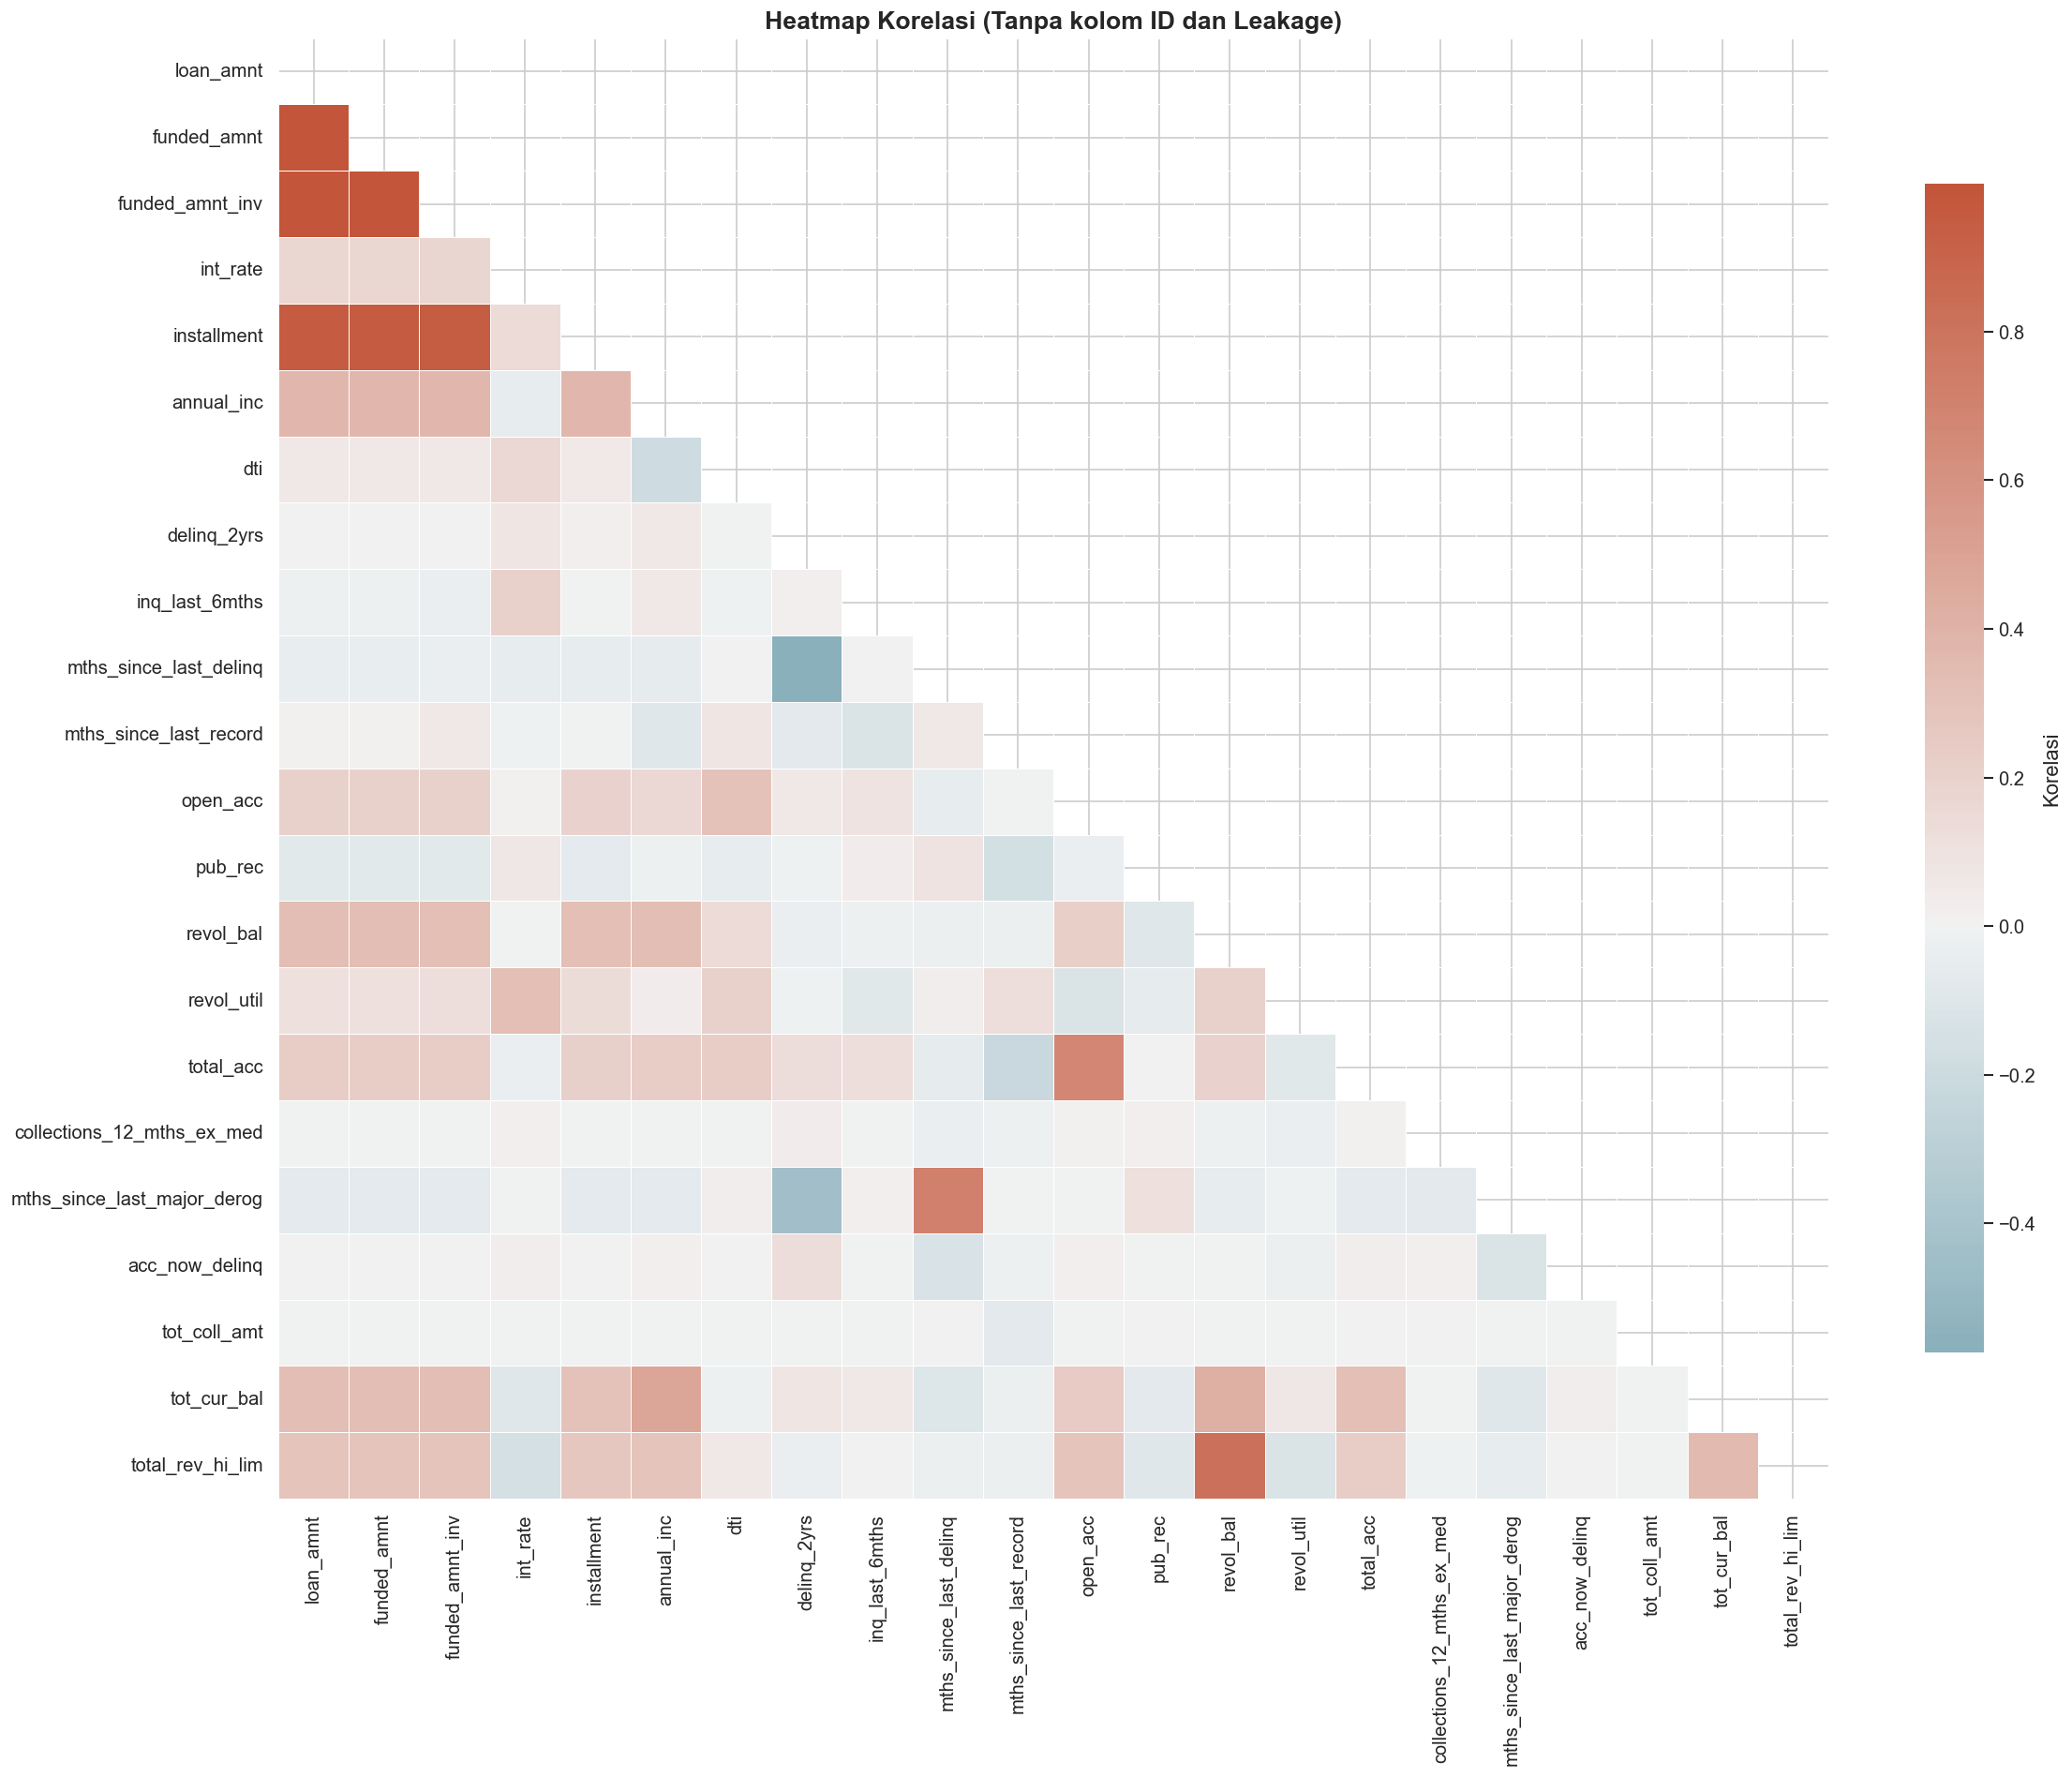

Top 10 pasangan fitur berkorelasi tinggi:
  loan_amnt                      - funded_amnt                    | r=0.999
  funded_amnt                    - funded_amnt_inv                | r=0.996
  loan_amnt                      - funded_amnt_inv                | r=0.994
  funded_amnt                    - installment                    | r=0.952
  loan_amnt                      - installment                    | r=0.950
  funded_amnt_inv                - installment                    | r=0.947
  revol_bal                      - total_rev_hi_lim               | r=0.810
  mths_since_last_delinq         - mths_since_last_major_derog    | r=0.722
  open_acc                       - total_acc                      | r=0.682
  delinq_2yrs                    - mths_since_last_delinq         | r=-0.574


In [115]:
exclude = ['id','member_id','policy_code','out_prncp','out_prncp_inv',
           'total_pymnt','total_pymnt_inv','total_rec_prncp','total_rec_int',
           'total_rec_late_fee','recoveries','collection_recovery_fee','last_pymnt_amnt']
num_df = df.select_dtypes(include=[np.number]).drop(
    columns=[c for c in exclude if c in df.columns]).dropna(axis=1, how='all')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, annot=False, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Korelasi'})
ax.set_title('Heatmap Korelasi (Tanpa kolom ID dan Leakage)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_correlation_heatmap.png')
plt.show()

# Top 10 korelasi
cp = corr.unstack().reset_index()
cp.columns = ['Kolom_1', 'Kolom_2', 'Korelasi']
cp = cp[cp['Kolom_1'] != cp['Kolom_2']]
cp['abs'] = cp['Korelasi'].abs()
cp = cp.drop_duplicates(subset='abs').sort_values('abs', ascending=False)
print('Top 10 pasangan fitur berkorelasi tinggi:')
for _, r in cp.head(10).iterrows():
    print(f'  {r.Kolom_1:30s} - {r.Kolom_2:30s} | r={r.Korelasi:.3f}')

## Step 4 — Analisis Kolom Kategorikal vs Loan Status
Setiap kolom kategorikal divisualisasikan dalam 2 panel: distribusi keseluruhan (kiri) dan proporsi Good vs Bad Loan (kanan). 
Target `loan_status` disederhanakan menjadi binary: **Good Loan** (Fully Paid, Current) dan **Bad Loan** (Charged Off, Default, Late, dll).

**Insight:**
- **Grade/Sub-grade:** Pola monoton sangat jelas — semakin rendah grade (E, F, G), semakin tinggi proporsi Bad Loan. Grade adalah fitur prediktif terkuat.
- **Purpose:** Pinjaman untuk `small_business` memiliki tingkat gagal bayar tertinggi.
- **Term:** Pinjaman 60 bulan memiliki risiko gagal bayar lebih tinggi dibanding 36 bulan.
- **Home Ownership:** Perbedaan risiko antar kategori relatif kecil.

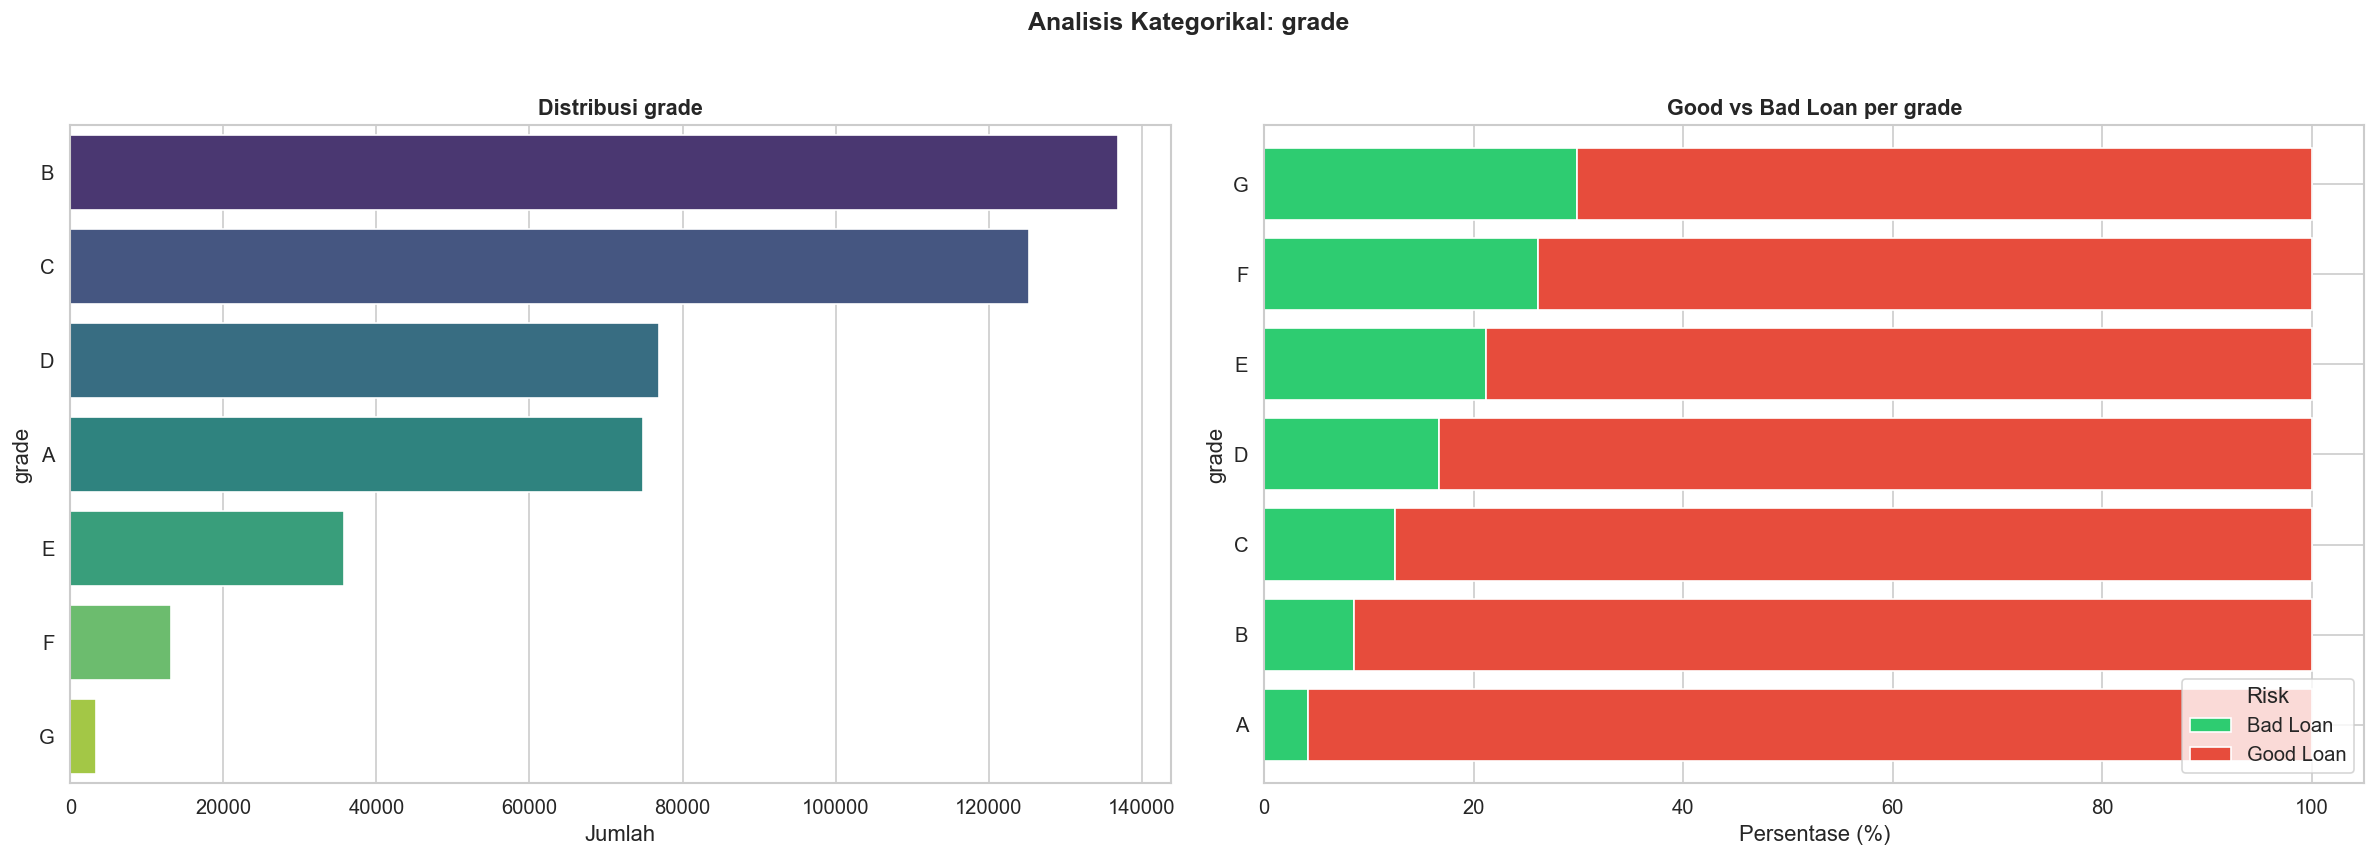

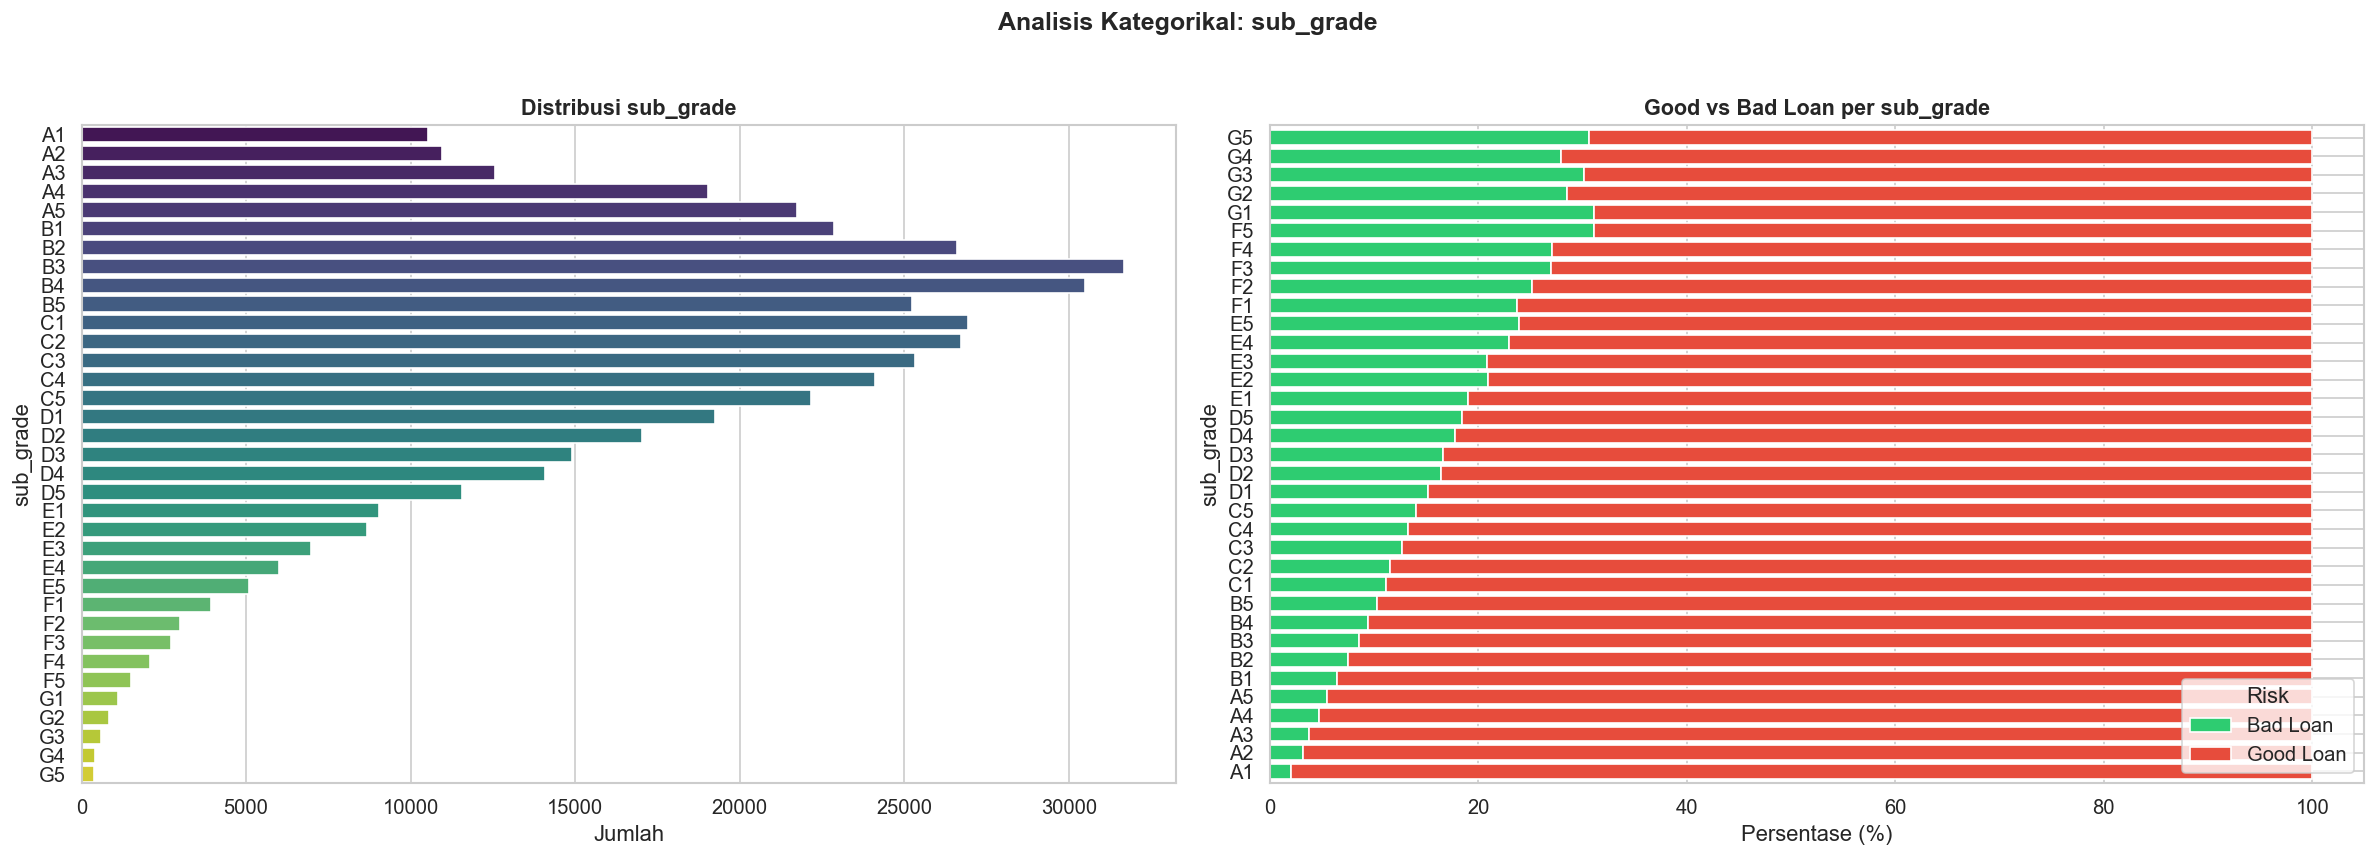

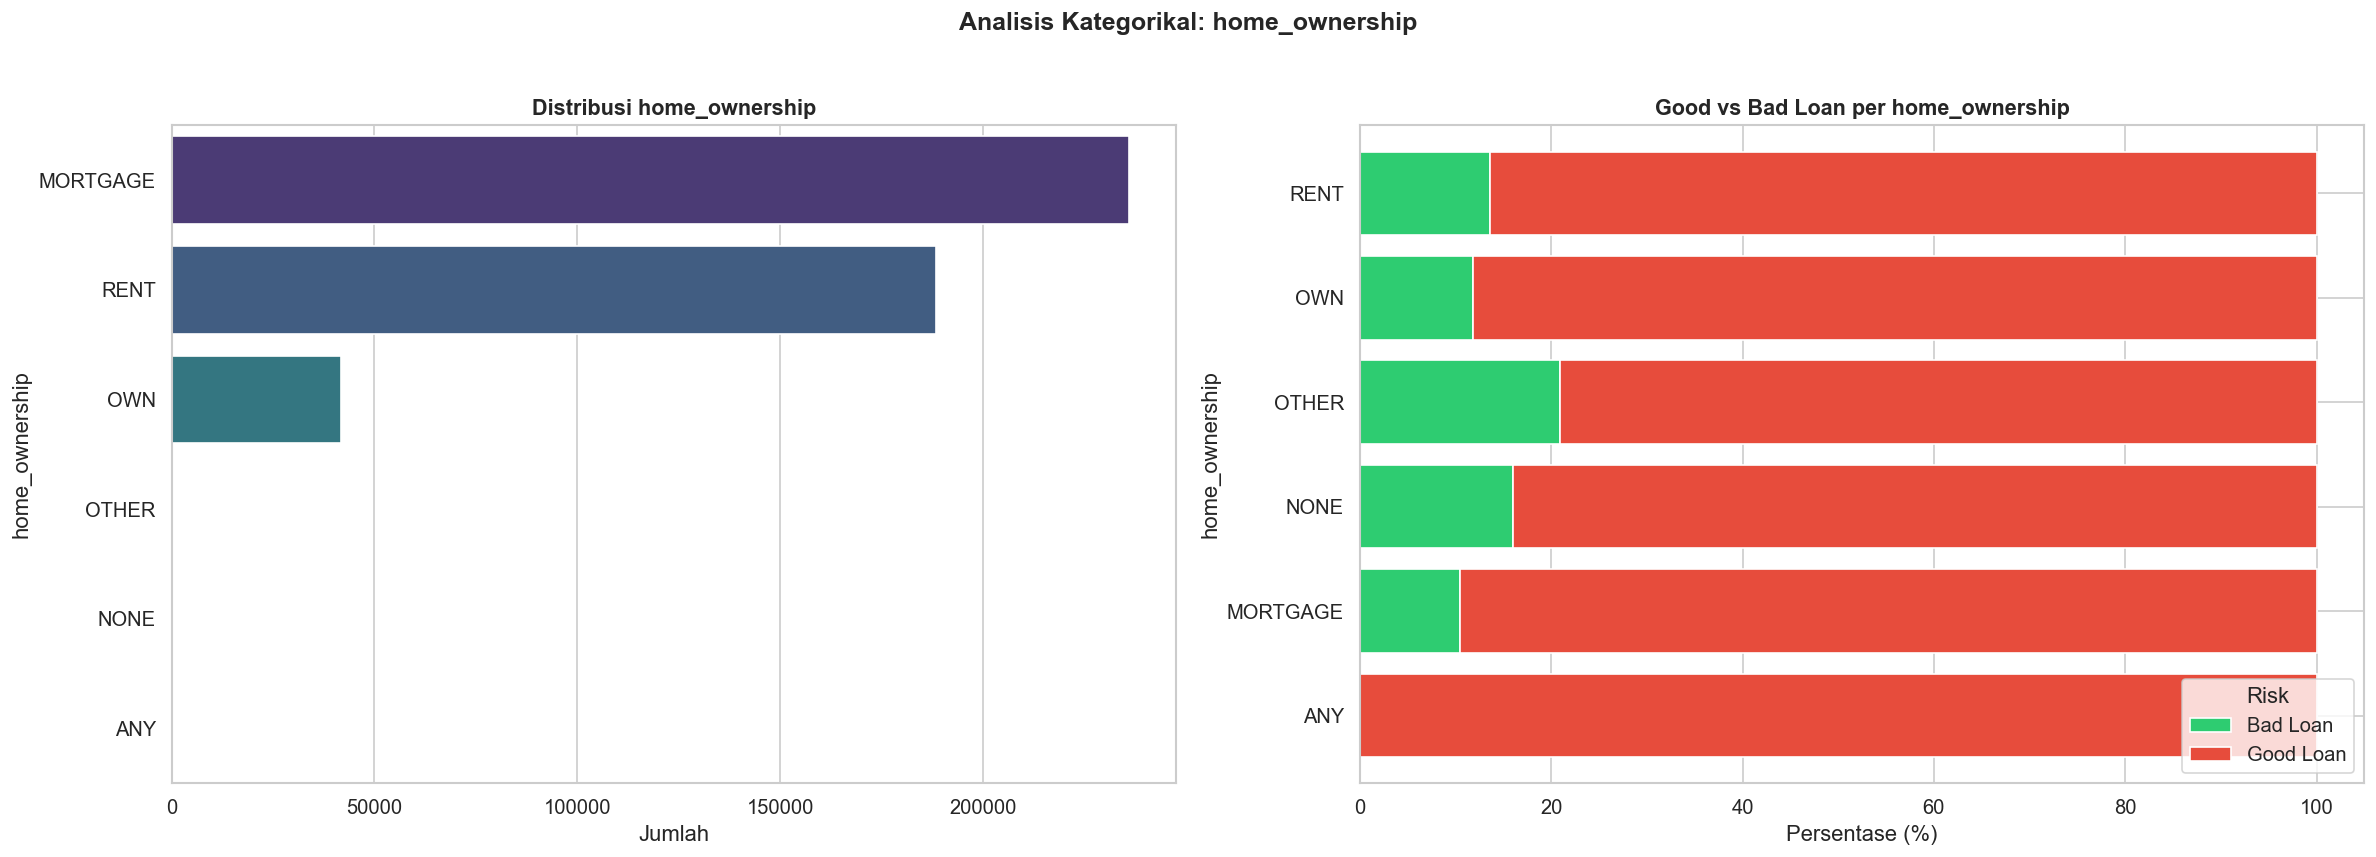

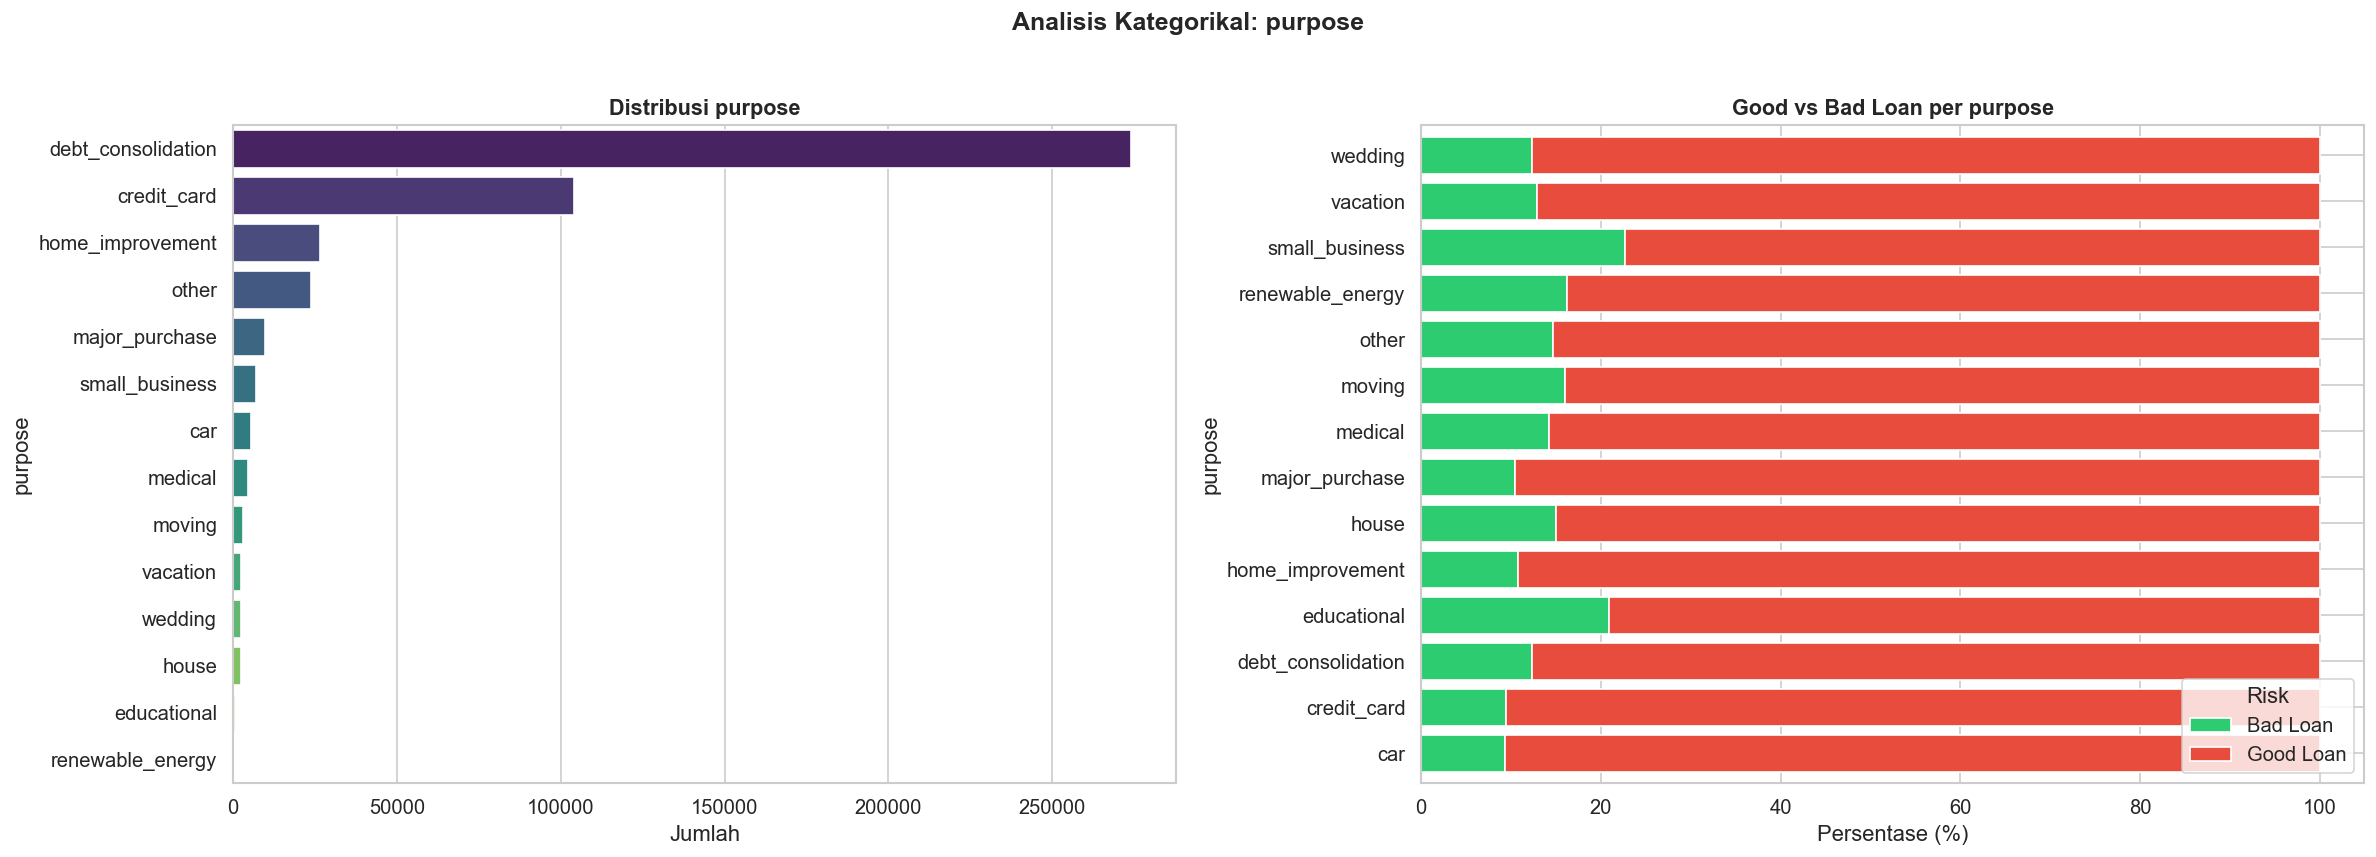

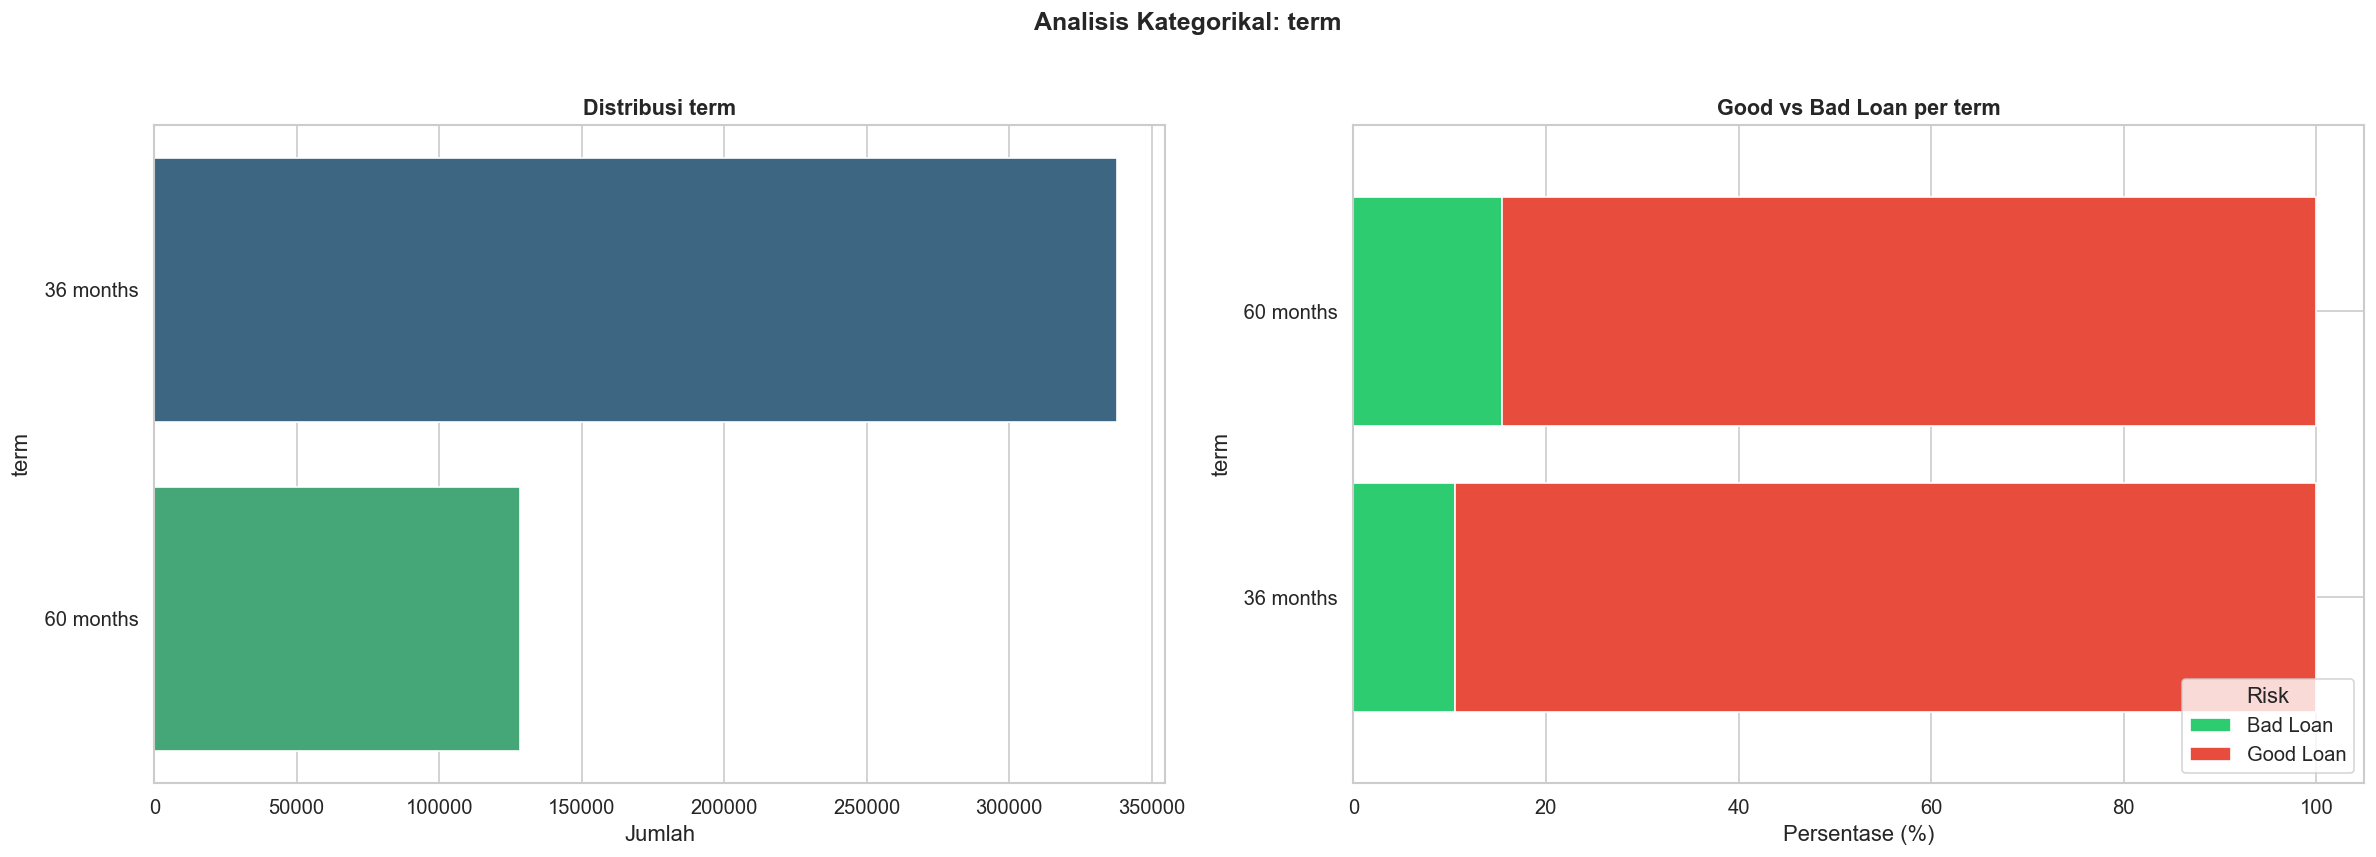

In [116]:
good = ['Fully Paid', 'Current', 'Does not meet the credit policy. Status:Fully Paid']
df['risk_label'] = df['loan_status'].apply(lambda x: 'Good Loan' if x in good else 'Bad Loan')

cat_cols = ['grade', 'sub_grade', 'home_ownership', 'purpose', 'term']
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    order_v = df[col].value_counts().index
    if col == 'sub_grade':
        order_v = sorted(df[col].dropna().unique())
    sns.countplot(y=col, data=df, order=order_v, palette='viridis', ax=axes[0])
    axes[0].set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Jumlah')

    ct = pd.crosstab(df[col], df['risk_label'], normalize='index') * 100
    if col == 'sub_grade':
        ct = ct.reindex(sorted(ct.index))
    ct.plot(kind='barh', stacked=True, ax=axes[1],
            color=['#2ecc71', '#e74c3c'], width=0.8)
    axes[1].set_title(f'Good vs Bad Loan per {col}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Persentase (%)')
    axes[1].legend(title='Risk', loc='lower right')

    plt.suptitle(f'Analisis Kategorikal: {col}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/04_categorical_{col}.png')
    plt.show()

## Step 5 — Distribusi Employment Length & Top 10 State
Panel kiri menunjukkan distribusi lama bekerja (`emp_length`), panel kanan menunjukkan 10 state dengan jumlah pinjaman terbanyak.

**Insight:** Peminjam dengan pengalaman **10+ tahun** mendominasi dataset (>100K), diikuti oleh peminjam < 1 tahun. 
Hal ini menunjukkan pola bimodal yang menarik. **California (CA)** memimpin jauh dengan jumlah pinjaman terbanyak, 
diikuti New York (NY) dan Texas (TX), yang konsisten dengan populasi dan aktivitas ekonomi.

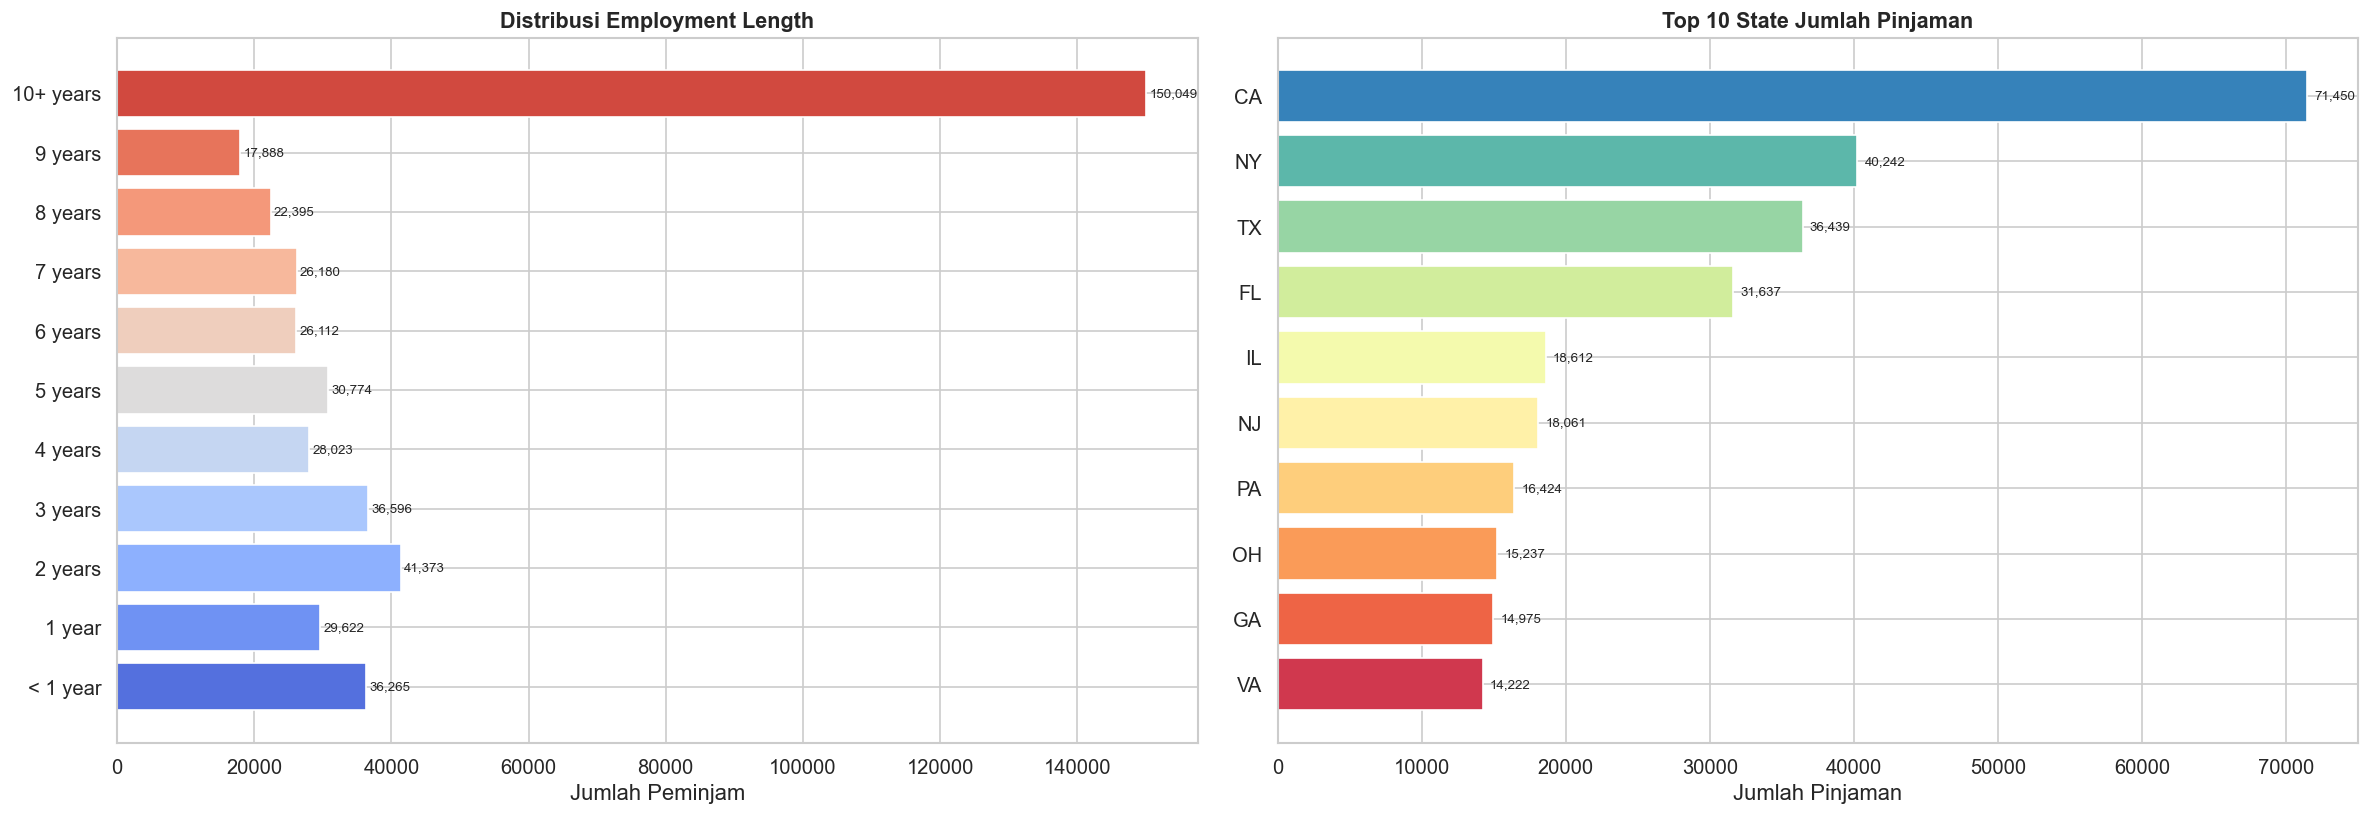

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

emp_order = ['< 1 year','1 year','2 years','3 years','4 years','5 years',
             '6 years','7 years','8 years','9 years','10+ years']
emp_counts = df['emp_length'].value_counts().reindex(emp_order).dropna()
bars1 = axes[0].barh(emp_counts.index, emp_counts.values,
                     color=sns.color_palette('coolwarm', len(emp_counts)))
axes[0].set_title('Distribusi Employment Length', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Peminjam')
for bar, val in zip(bars1, emp_counts.values):
    axes[0].text(val+500, bar.get_y()+bar.get_height()/2,
                f'{int(val):,}', va='center', fontsize=8)

top_states = df['addr_state'].value_counts().head(10)
bars2 = axes[1].barh(top_states.index[::-1], top_states.values[::-1],
                     color=sns.color_palette('Spectral', 10))
axes[1].set_title('Top 10 State Jumlah Pinjaman', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Pinjaman')
for bar, val in zip(bars2, top_states.values[::-1]):
    axes[1].text(val+500, bar.get_y()+bar.get_height()/2,
                f'{int(val):,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_emp_length_addr_state.png')
plt.show()

## Step 6 — Boxplot Deteksi Outlier
Boxplot digunakan untuk mengidentifikasi outlier pada 8 kolom numerik menggunakan metode IQR (1.5 x Interquartile Range). 
Setiap boxplot dilengkapi informasi jumlah dan persentase outlier.

**Insight:** Kolom `annual_inc` dan `revol_bal` memiliki outlier paling signifikan — ada peminjam dengan pendapatan >$7.5 juta dan saldo revolving >$2.5 juta. 
Kolom `dti` juga menunjukkan outlier di atas 35%. Outlier ini perlu ditangani pada preprocessing dengan teknik seperti 
winsorizing (capping pada persentil 1-99), log transformation, atau removal.

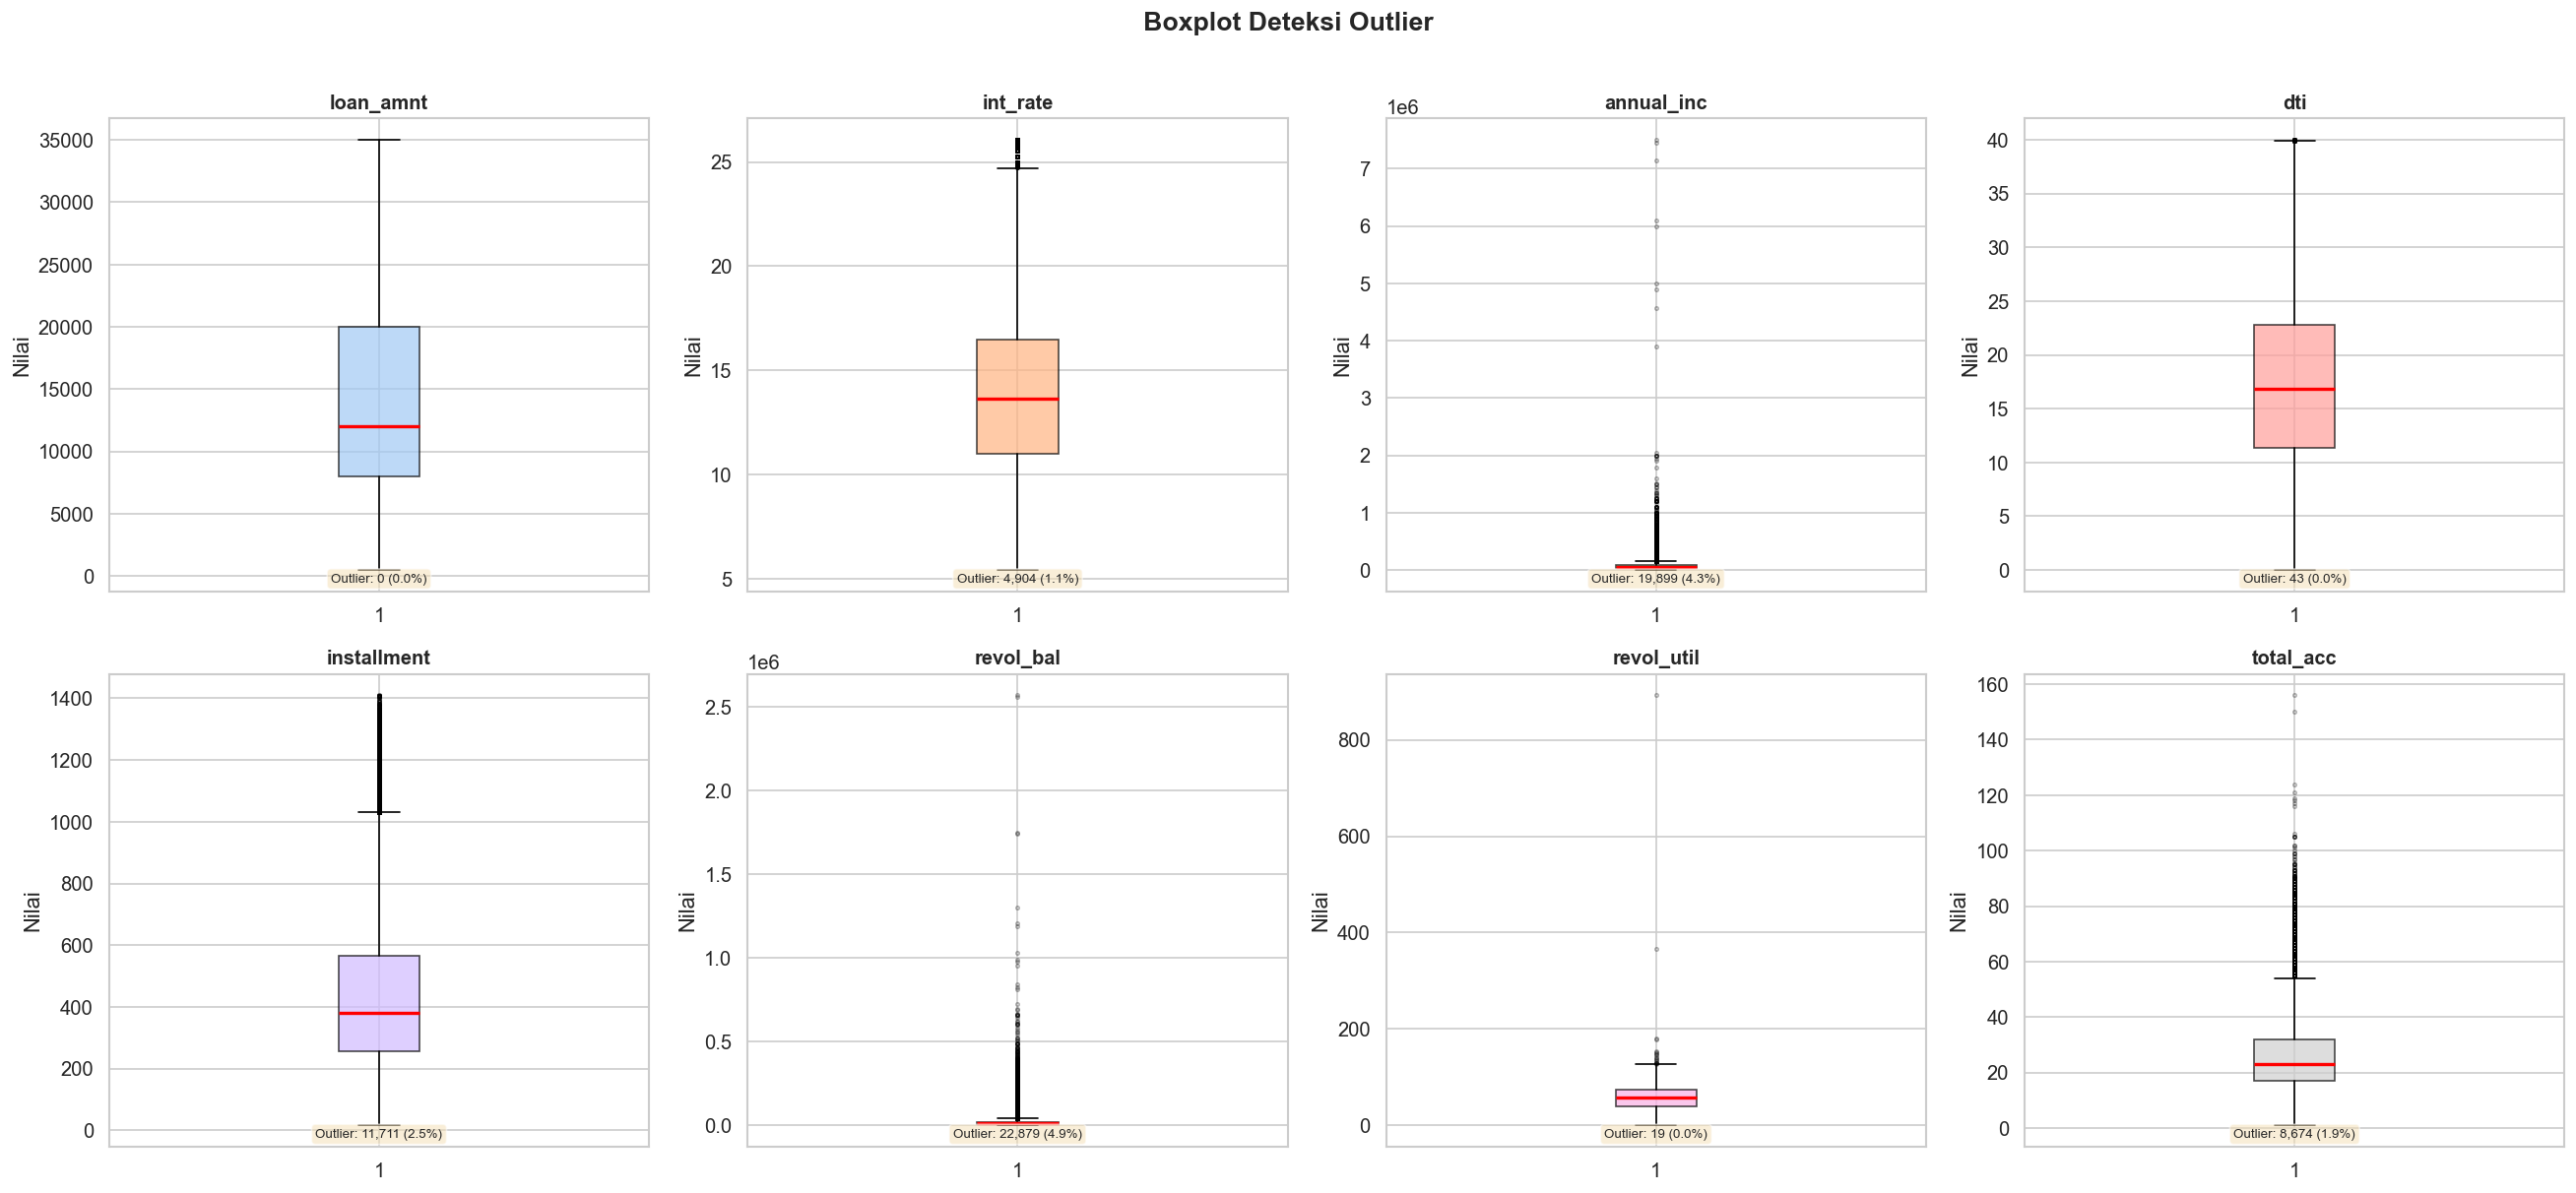

In [118]:
outlier_cols = ['loan_amnt','int_rate','annual_inc','dti',
                'installment','revol_bal','revol_util','total_acc']
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('pastel')[i], alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai')
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    pct_out = n_out / len(data) * 100
    axes[i].text(0.5, 0.02, f'Outlier: {n_out:,} ({pct_out:.1f}%)',
                transform=axes[i].transAxes, ha='center', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Boxplot Deteksi Outlier', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/06_outlier_boxplots.png')
plt.show()

---
## Kesimpulan Stage 2 EDA

Dari analisis visualisasi lengkap, beberapa temuan utama:

1. **Target imbalanced** — Good Loan ~88%, Bad Loan ~12%. Perlu handling khusus (SMOTE, class weight)
2. **Grade & sub_grade** adalah prediktor terkuat — pola monoton risiko sangat jelas
3. **Korelasi tinggi** antara `loan_amnt`/`funded_amnt`/`installment` (r > 0.9) — drop salah satu
4. **Outlier signifikan** pada `annual_inc`, `revol_bal` — perlu capping/log transform
5. **Small business loans** memiliki risiko gagal bayar tertinggi berdasarkan `purpose`
6. **Pinjaman 60 bulan** lebih berisiko dibanding 36 bulan

**Langkah selanjutnya:** Stage 3 — Data Cleaning & Preprocessing


---
# Stage 3
---

## Import Library & Load Data
Kita mengimpor `pandas` untuk manipulasi data, `numpy` untuk operasi numerik, dan `LabelEncoder` dari scikit-learn untuk encoding variabel ordinal. 
Dataset di-load dan shape awal dicatat untuk perbandingan setelah preprocessing selesai.

In [119]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('data/loan_data_2007_2014.csv', index_col=0, low_memory=False)
shape_before = df.shape
print(f'Shape awal: {df.shape}')

Shape awal: (466285, 74)


## Step 1 — Binarisasi Target Variable
Kolom `loan_status` awalnya memiliki 9 kategori. Untuk binary classification, kita hanya mempertahankan dua kelas yang jelas hasilnya:
- **0 (Good Loan):** `Fully Paid` — pinjaman sudah lunas
- **1 (Bad Loan):** `Charged Off` dan `Default` — pinjaman gagal bayar

Baris dengan status lain (`Current`, `Late`, `In Grace Period`, `Does not meet...`) di-drop karena:
- `Current` = pinjaman masih berjalan, hasilnya belum diketahui
- `Late/Grace Period` = status sementara, belum final
- `Does not meet...` = policy exception, bukan populasi umum

In [120]:
print('Distribusi awal:')
print(df['loan_status'].value_counts())

target_map = {'Fully Paid': 0, 'Charged Off': 1, 'Default': 1}
df = df[df['loan_status'].isin(target_map.keys())].copy()
df['loan_status'] = df['loan_status'].map(target_map)

print(f'\nBaris setelah filter: {len(df):,}')
print(f'Distribusi target baru:\n{df["loan_status"].value_counts()}')
print(f'Persentase Bad Loan: {df["loan_status"].mean()*100:.2f}%')

Distribusi awal:
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Baris setelah filter: 228,046
Distribusi target baru:
loan_status
0    184739
1     43307
Name: count, dtype: int64
Persentase Bad Loan: 18.99%


## Step 2 — Drop Kolom Tidak Relevan
Kolom-kolom berikut dihapus karena tidak memberikan nilai prediktif:

- **Kolom identitas** (`id`, `member_id`, `url`, `desc`, `title`, `zip_code`): hanya identifier unik atau teks tidak terstruktur
- **Kolom missing >50%**: terlalu banyak data hilang untuk diimputasi secara reliable (`mths_since_last_delinq`, `mths_since_last_record`, `mths_since_last_major_derog`, dll)
- **Kolom post-loan (data leakage)**: informasi seperti `total_pymnt`, `recoveries`, `last_pymnt_amnt` hanya tersedia SETELAH pinjaman berjalan — menggunakan ini = curang
- **Kolom zero-variance**: `policy_code` (semua bernilai 1) tidak punya daya pembeda

In [121]:
cols_before = df.shape[1]

# 2a. Kolom identitas
id_cols = ['id','member_id','url','desc','title','zip_code']
df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)
print(f'[2a] Drop identitas: {len(id_cols)} kolom')

# 2b. Missing > 50%
missing_pct = df.isnull().sum() / len(df) * 100
high_missing = missing_pct[missing_pct > 50].index.tolist()
df.drop(columns=high_missing, inplace=True)
print(f'[2b] Drop missing >50%: {high_missing}')

# 2c. Post-loan leakage
post_loan = ['funded_amnt','funded_amnt_inv','out_prncp','out_prncp_inv',
             'total_pymnt','total_pymnt_inv','total_rec_prncp','total_rec_int',
             'total_rec_late_fee','recoveries','collection_recovery_fee',
             'last_pymnt_d','last_pymnt_amnt','next_pymnt_d',
             'last_credit_pull_d','pymnt_plan']
df.drop(columns=[c for c in post_loan if c in df.columns], inplace=True)
print(f'[2c] Drop post-loan: {len(post_loan)} kolom')

# 2d. Zero-variance
for c in df.columns:
    if df[c].nunique(dropna=True) <= 1:
        print(f'[2d] Drop zero-variance: {c}')
        df.drop(columns=[c], inplace=True)

print(f'\nKolom: {cols_before} -> {df.shape[1]} (dropped {cols_before - df.shape[1]})')

[2a] Drop identitas: 6 kolom
[2b] Drop missing >50%: ['mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m']
[2c] Drop post-loan: 16 kolom
[2d] Drop zero-variance: policy_code
[2d] Drop zero-variance: application_type

Kolom: 74 -> 30 (dropped 44)


## Step 3 — Handle Missing Values
Strategi pengisian missing values:
- **Kolom numerik → median:** Median dipilih karena lebih robust terhadap outlier dibanding mean. 
Kolom seperti `annual_inc` memiliki outlier ekstrem, sehingga mean akan bias.
- **Kolom kategorikal → modus:** Mengisi dengan nilai yang paling sering muncul adalah pendekatan yang paling konservatif 
dan tidak mengubah distribusi data secara signifikan.

In [122]:
missing_before = df.isnull().sum().sum()
print(f'Total missing sebelum: {missing_before:,}')

# Numerik -> median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_status']
for c in num_cols:
    n = df[c].isnull().sum()
    if n > 0:
        med = df[c].median()
        df[c] = df[c].fillna(med)
        print(f'  [Num] {c:30s} | {n:>6,} -> median ({med:.2f})')

# Kategorikal -> modus
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
for c in cat_cols:
    n = df[c].isnull().sum()
    if n > 0:
        mode = df[c].mode()[0]
        df[c] = df[c].fillna(mode)
        print(f'  [Cat] {c:30s} | {n:>6,} -> modus ({mode})')

print(f'\nTotal missing sesudah: {df.isnull().sum().sum()}')

Total missing sebelum: 212,899
  [Num] revol_util                     |    186 -> median (56.50)
  [Num] collections_12_mths_ex_med     |     56 -> median (0.00)
  [Num] tot_coll_amt                   | 63,726 -> median (0.00)
  [Num] tot_cur_bal                    | 63,726 -> median (80282.00)
  [Num] total_rev_hi_lim               | 63,726 -> median (22100.00)
  [Cat] emp_title                      | 12,758 -> modus (Teacher)
  [Cat] emp_length                     |  8,721 -> modus (10+ years)

Total missing sesudah: 0


## Step 4 — Feature Engineering
Transformasi fitur agar siap digunakan oleh model:

- **`term`**: Mengandung string ` 36 months` / ` 60 months` — diekstrak angkanya saja
- **`int_rate` & `revol_util`**: Dicek apakah masih string (mengandung `%`), jika ya dikonversi ke float
- **`credit_history_years`**: Fitur baru yang dihitung dari selisih `issue_d` (tanggal pinjaman diterbitkan) dan `earliest_cr_line` (tanggal kredit pertama). 
Semakin lama riwayat kredit, umumnya semakin rendah risikonya
- **`emp_length`**: Dikonversi ke skala 0-10 (`< 1 year`=0, `10+ years`=10)
- **`verification_status`**: Diubah ke ordinal (Not Verified=0, Source Verified=1, Verified=2)

In [123]:
# 4a. term -> numerik
if 'term' in df.columns:
    df['term'] = df['term'].str.strip().str.replace(' months','',regex=False).astype(int)
    print(f'[4a] term: {df["term"].unique()}')

# 4b. int_rate & revol_util
for col in ['int_rate', 'revol_util']:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace('%','',regex=False).astype(float)
            print(f'[4b] {col} -> hapus %, convert float')
        else:
            print(f'[4b] {col} -> sudah float ({df[col].dtype})')

# 4c. credit_history_years
if 'earliest_cr_line' in df.columns and 'issue_d' in df.columns:
    df['earliest_cr_line_dt'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
    df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
    mask_cr = df['earliest_cr_line_dt'].dt.year > 2025
    df.loc[mask_cr, 'earliest_cr_line_dt'] -= pd.DateOffset(years=100)
    mask_issue = df['issue_d_dt'].dt.year > 2025
    df.loc[mask_issue, 'issue_d_dt'] -= pd.DateOffset(years=100)
    df['credit_history_years'] = ((df['issue_d_dt'] - df['earliest_cr_line_dt']).dt.days / 365.25).round(1)
    df.drop(columns=['earliest_cr_line','issue_d','earliest_cr_line_dt','issue_d_dt'], inplace=True)
    print(f'[4c] credit_history_years -> mean: {df["credit_history_years"].mean():.1f}')

# 4d. emp_length -> 0-10
if 'emp_length' in df.columns:
    emp_map = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,
              '5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9,'10+ years':10}
    df['emp_length'] = df['emp_length'].astype(str).map(emp_map)
    med_emp = df['emp_length'].median()
    df['emp_length'] = df['emp_length'].fillna(med_emp).astype(int)
    print(f'[4d] emp_length: {sorted(df["emp_length"].unique())}')

# 4e. verification_status -> ordinal
if 'verification_status' in df.columns:
    verif_map = {'Not Verified':0, 'Source Verified':1, 'Verified':2}
    df['verification_status'] = df['verification_status'].map(verif_map)
    df['verification_status'] = df['verification_status'].fillna(0).astype(int)
    print(f'[4e] verification_status: {sorted(df["verification_status"].unique())}')

[4a] term: [36 60]
[4b] int_rate -> sudah float (float64)
[4b] revol_util -> sudah float (float64)
[4c] credit_history_years -> mean: 15.2
[4d] emp_length: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
[4e] verification_status: [np.int64(0), np.int64(1), np.int64(2)]


## Step 5 — Encoding Kolom Kategorikal
Dua teknik encoding digunakan sesuai sifat data:

- **Label Encoding** untuk `grade` dan `sub_grade`: Kedua kolom ini bersifat **ordinal** (A > B > C > ... > G), 
sehingga label encoding yang mempertahankan urutan adalah pilihan yang tepat.
- **One-Hot Encoding** untuk `home_ownership`, `purpose`, `initial_list_status`, `addr_state`: 
Kolom-kolom ini bersifat **nominal** (tidak ada urutan), sehingga one-hot encoding dipilih agar model tidak salah menginterpretasikan angka sebagai urutan. 
Parameter `drop_first=True` menghilangkan satu dummy variable untuk menghindari multikolinearitas.

In [124]:
# 5a. Label Encoding (ordinal)
for col in ['grade', 'sub_grade']:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f'[Label Enc] {col}: {len(le.classes_)} kelas')

# 5b. One-Hot Encoding (nominal)
ohe_cols = ['home_ownership','purpose','initial_list_status']
if 'application_type' in df.columns: ohe_cols.append('application_type')
if 'addr_state' in df.columns: ohe_cols.append('addr_state')
existing = [c for c in ohe_cols if c in df.columns]
print(f'\n[One-Hot Enc] Kolom: {existing}')
for c in existing:
    print(f'  {c}: {df[c].nunique()} kategori')
df = pd.get_dummies(df, columns=existing, drop_first=True, dtype=int)
print(f'\nKolom setelah encoding: {df.shape[1]}')

[Label Enc] grade: 7 kelas
[Label Enc] sub_grade: 35 kelas

[One-Hot Enc] Kolom: ['home_ownership', 'purpose', 'initial_list_status', 'addr_state']
  home_ownership: 6 kategori
  purpose: 14 kategori
  initial_list_status: 2 kategori
  addr_state: 50 kategori

Kolom setelah encoding: 93


## Step 6 — Validasi Final & Drop Kolom Non-Numerik Tersisa
Pengecekan terakhir untuk memastikan semua kolom sudah bertipe numerik. 
Jika masih ada kolom bertipe `object` (string) yang terlewat, kolom tersebut akan di-drop. 
Hal ini penting karena sebagian besar algoritma machine learning hanya menerima input numerik.

In [125]:
remaining = df.select_dtypes(include=['object']).columns.tolist()
if remaining:
    print(f'Drop kolom non-numerik tersisa: {remaining}')
    df.drop(columns=remaining, inplace=True)
else:
    print('Semua kolom sudah numerik.')

Drop kolom non-numerik tersisa: ['emp_title']


## Step 7 — Ringkasan & Simpan Dataset Bersih
Menampilkan perbandingan shape sebelum dan sesudah preprocessing, distribusi target, dan 5 baris pertama dataset bersih. 
Dataset yang sudah diproses disimpan ke `loan_data_preprocessed.csv` untuk digunakan pada tahap modeling selanjutnya.

In [126]:
df_clean = df.copy()

print(f'Shape SEBELUM : {shape_before}')
print(f'Shape SESUDAH : {df_clean.shape}')
print(f'Baris dihapus : {shape_before[0] - df_clean.shape[0]:,}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
print(f'\nDistribusi target:\n{df_clean["loan_status"].value_counts()}')

df_clean.to_csv('data/loan_data_preprocessed.csv', index=False)
print(f'\nDisimpan: loan_data_preprocessed.csv ({df_clean.shape[0]:,} x {df_clean.shape[1]})')

Shape SEBELUM : (466285, 74)
Shape SESUDAH : (228046, 92)
Baris dihapus : 238,239
Missing values: 0

Distribusi target:
loan_status
0    184739
1     43307
Name: count, dtype: int64

Disimpan: loan_data_preprocessed.csv (228,046 x 92)


In [127]:
df_clean.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,loan_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,credit_history_years,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,addr_state_AL,addr_state_AR,addr_state_AZ,addr_state_CA,addr_state_CO,addr_state_CT,addr_state_DC,addr_state_DE,addr_state_FL,addr_state_GA,addr_state_HI,addr_state_IA,addr_state_ID,addr_state_IL,addr_state_IN,addr_state_KS,addr_state_KY,addr_state_LA,addr_state_MA,addr_state_MD,addr_state_ME,addr_state_MI,addr_state_MN,addr_state_MO,addr_state_MS,addr_state_MT,addr_state_NC,addr_state_NE,addr_state_NH,addr_state_NJ,addr_state_NM,addr_state_NV,addr_state_NY,addr_state_OH,addr_state_OK,addr_state_OR,addr_state_PA,addr_state_RI,addr_state_SC,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
0,5000,36,10.65,162.87,1,6,10,24000.0,2,0,27.65,0.0,1.0,3.0,0.0,13648,83.7,9.0,0.0,0.0,0.0,80282.0,22100.0,26.9,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2500,60,15.27,59.83,2,13,0,30000.0,1,1,1.00,0.0,5.0,3.0,0.0,1687,9.4,4.0,0.0,0.0,0.0,80282.0,22100.0,12.7,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2400,36,15.96,84.33,2,14,10,12252.0,0,0,8.72,0.0,2.0,2.0,0.0,2956,98.5,10.0,0.0,0.0,0.0,80282.0,22100.0,10.1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,10000,36,13.49,339.31,2,10,10,49200.0,1,0,20.00,0.0,1.0,10.0,0.0,5598,21.0,37.0,0.0,0.0,0.0,80282.0,22100.0,15.8,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,5000,36,7.90,156.46,0,3,3,36000.0,1,0,11.20,0.0,3.0,9.0,0.0,7963,28.3,12.0,0.0,0.0,0.0,80282.0,22100.0,7.1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


---
## Kesimpulan Preprocessing

Dataset telah melalui 7 tahap preprocessing dan siap untuk modeling:
1. Target binary (Fully Paid=0, Charged Off/Default=1)
2. Kolom tidak relevan, leakage, dan zero-variance telah dihapus
3. Missing values telah diisi (median/modus)
4. Fitur baru `credit_history_years` telah dibuat
5. Semua kolom sudah numerik (label/one-hot encoded)

**Langkah selanjutnya:** Stage 4 — Feature Selection & Modeling


---
# Stage 4
---

## Import Library & Load Data
Kita mengimpor `train_test_split` untuk membagi data, `StandardScaler` untuk normalisasi fitur, dan `SMOTE` dari `imbalanced-learn` untuk menangani ketidakseimbangan kelas. 
Dataset yang sudah dipreprocessing di Stage 3 di-load dari file CSV.

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SAVE_DIR = 'images'
for d in ['data','images','models']:
    os.makedirs(d, exist_ok=True)

df_clean = pd.read_csv('data/loan_data_preprocessed.csv')
print(f'Dataset: {df_clean.shape[0]:,} x {df_clean.shape[1]}')

Dataset: 228,046 x 92


## Step 1 — Pisahkan Fitur (X) dan Target (y)
Langkah pertama dalam pipeline modeling adalah memisahkan variabel independen (fitur/X) dari variabel dependen (target/y). 
Kolom `loan_status` menjadi target karena itu adalah variabel yang ingin kita prediksi — apakah peminjam akan gagal bayar (1) atau tidak (0). 
Semua kolom lainnya menjadi fitur yang akan digunakan model untuk belajar pola credit risk.

In [129]:
X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Fitur ({X.shape[1]} total): {list(X.columns[:10])}...')

X shape: (228046, 91)
y shape: (228046,)
Fitur (91 total): ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'verification_status', 'dti']...


## Step 2 — Proporsi Kelas & Visualisasi
Dalam konteks **credit risk**, distribusi kelas target sangat penting karena kasus gagal bayar (Bad Loan) biasanya jauh lebih sedikit dibanding pinjaman lunas (Good Loan). 
Ini disebut **class imbalance** dan merupakan tantangan utama dalam fraud/risk detection.

**Mengapa ini masalah?** Jika model dilatih pada data imbalanced tanpa penanganan, model akan cenderung memprediksi semua data sebagai kelas mayoritas (Good Loan) dan mendapatkan akurasi tinggi (~81%) padahal **gagal total mendeteksi Bad Loan** — yang justru adalah tujuan utama kita.

**Insight:** Rasio Good:Bad sekitar **4.3:1**, yang termasuk **imbalanced** dan memerlukan penanganan khusus seperti SMOTE.

Kelas 0 (Good Loan) : 184,739 (81.01%)
Kelas 1 (Bad Loan)  : 43,307 (18.99%)
Rasio Good:Bad      : 4.3 : 1
>> Dataset IMBALANCED (rasio 4.3:1, threshold > 3:1)


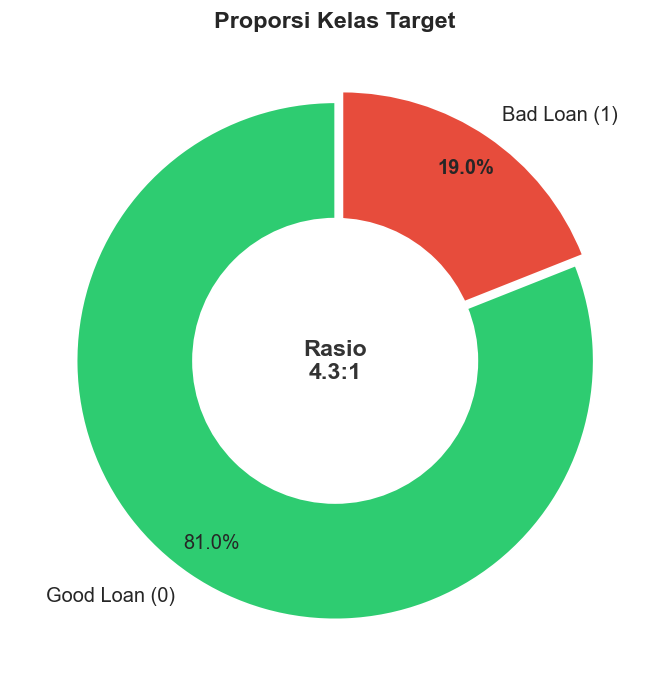

In [130]:
class_counts = y.value_counts()
class_pct = y.value_counts(normalize=True) * 100

print(f'Kelas 0 (Good Loan) : {class_counts[0]:,} ({class_pct[0]:.2f}%)')
print(f'Kelas 1 (Bad Loan)  : {class_counts[1]:,} ({class_pct[1]:.2f}%)')
imbalance_ratio = class_counts[0] / class_counts[1]
print(f'Rasio Good:Bad      : {imbalance_ratio:.1f} : 1')
if imbalance_ratio > 3:
    print(f'>> Dataset IMBALANCED (rasio {imbalance_ratio:.1f}:1, threshold > 3:1)')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']
labels = ['Good Loan (0)', 'Bad Loan (1)']
wedges, texts, autotexts = ax.pie(
    class_counts.values, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90, explode=[0, 0.05],
    textprops={'fontsize': 12}, pctdistance=0.85)
autotexts[1].set_fontweight('bold')
centre = plt.Circle((0,0), 0.55, fc='white')
ax.add_artist(centre)
ax.set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')
ax.text(0, 0, f'Rasio\n{imbalance_ratio:.1f}:1', ha='center', va='center', fontsize=14, fontweight='bold', color='#333')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_target_proportion.png')
plt.show()

## Step 3 — Train-Test Split (80:20, Stratified)
Data dibagi menjadi **80% training** dan **20% testing** dengan `stratify=y` untuk menjaga proporsi kelas tetap sama di kedua subset. 
Ini penting karena jika split dilakukan secara random tanpa stratifikasi, bisa terjadi satu subset mendapat proporsi Bad Loan yang sangat berbeda, yang akan membuat evaluasi model tidak representatif.

`random_state=42` digunakan agar hasil split **reproducible** — siapa pun yang menjalankan kode ini akan mendapatkan pembagian data yang sama persis.

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train distribusi: {dict(y_train.value_counts())}')
print(f'y_test  distribusi: {dict(y_test.value_counts())}')
print(f'Bad Loan — train: {y_train.mean()*100:.2f}%, test: {y_test.mean()*100:.2f}%')

X_train : (182436, 91)
X_test  : (45610, 91)
y_train distribusi: {0: np.int64(147791), 1: np.int64(34645)}
y_test  distribusi: {0: np.int64(36948), 1: np.int64(8662)}
Bad Loan — train: 18.99%, test: 18.99%


## Step 4 — SMOTE (Hanya pada Train Set)
**SMOTE (Synthetic Minority Oversampling Technique)** membuat sampel sintetis baru untuk kelas minoritas (Bad Loan) 
berdasarkan interpolasi antara sampel-sampel minoritas yang berdekatan di feature space.

> **Mengapa SMOTE hanya dilakukan di train set, BUKAN di test set?**

Ini adalah prinsip fundamental dalam machine learning:
1. **Test set harus merepresentasikan data dunia nyata.** Di dunia nyata, rasio bad loan memang jauh lebih kecil. Jika kita SMOTE test set, evaluasi model menjadi tidak realistis.
2. **Mencegah data leakage.** Jika SMOTE dilakukan sebelum split, sampel sintetis bisa "bocor" dari train ke test, membuat model terlihat lebih baik dari kenyataannya.
3. **Evaluasi yang jujur.** Model harus diuji pada distribusi asli untuk mengetahui performa sebenarnya di production.

Setelah SMOTE, jumlah kelas 0 dan kelas 1 di train set menjadi **seimbang (1:1)**.

SEBELUM SMOTE:
  Kelas 0: 147,791
  Kelas 1: 34,645

SESUDAH SMOTE:
  Kelas 0: 147,791
  Kelas 1: 147,791
  Total  : 295,582


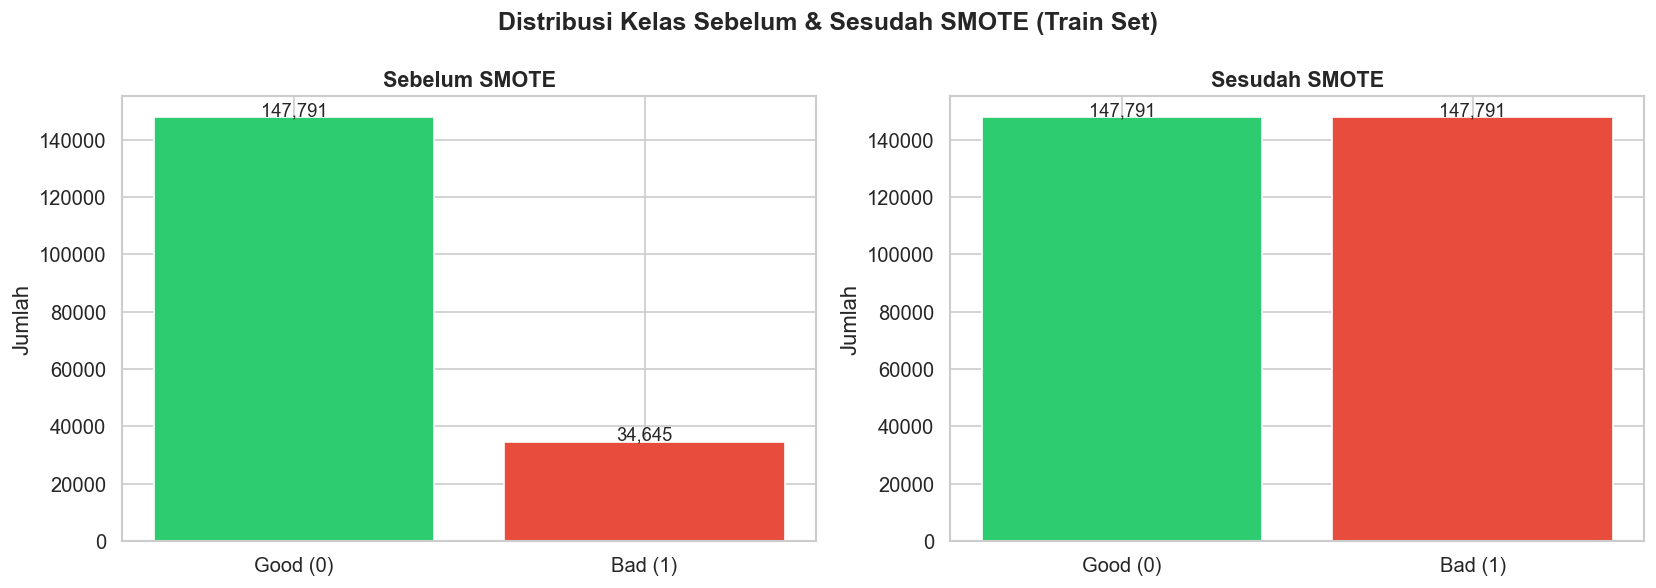

In [132]:
print('SEBELUM SMOTE:')
print(f'  Kelas 0: {(y_train==0).sum():,}')
print(f'  Kelas 1: {(y_train==1).sum():,}')

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'\nSESUDAH SMOTE:')
print(f'  Kelas 0: {(y_train_res==0).sum():,}')
print(f'  Kelas 1: {(y_train_res==1).sum():,}')
print(f'  Total  : {len(y_train_res):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

before = y_train.value_counts()
axes[0].bar(['Good (0)','Bad (1)'], before.values, color=colors, edgecolor='white')
axes[0].set_title('Sebelum SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i,v in enumerate(before.values):
    axes[0].text(i, v+500, f'{v:,}', ha='center', fontsize=11)

after = pd.Series(y_train_res).value_counts()
axes[1].bar(['Good (0)','Bad (1)'], after.values, color=colors, edgecolor='white')
axes[1].set_title('Sesudah SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah')
for i,v in enumerate(after.values):
    axes[1].text(i, v+500, f'{v:,}', ha='center', fontsize=11)

plt.suptitle('Distribusi Kelas Sebelum & Sesudah SMOTE (Train Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_smote_comparison.png')
plt.show()

## Step 5 — Feature Scaling (StandardScaler)
**StandardScaler** mentransformasi setiap fitur agar memiliki **mean=0** dan **standard deviation=1**. 
Ini penting karena banyak algoritma ML (seperti Logistic Regression, SVM, KNN) sensitif terhadap skala fitur.

> **Mengapa scaler hanya di-fit pada train set?**

1. **Mencegah data leakage.** Jika scaler di-fit pada seluruh data (termasuk test), informasi statistik (mean, std) dari test set akan "bocor" ke proses training.
2. **Simulasi production.** Di dunia nyata, kita tidak akan memiliki data masa depan saat melatih model. Scaler harus di-fit hanya pada data yang tersedia saat training.
3. **Konsistensi.** Test set di-transform menggunakan parameter (mean, std) yang sama dari train set, memastikan skala konsisten.

Scaler juga disimpan ke file `scaler.pkl` menggunakan `joblib` agar bisa di-load kembali saat deployment/inference.

In [133]:
scaler = StandardScaler()
X_train_res = pd.DataFrame(
    scaler.fit_transform(X_train_res), columns=X.columns)
X_test = pd.DataFrame(
    scaler.transform(X_test), columns=X.columns)

joblib.dump(scaler, 'models/scaler.pkl')
print('Scaler fit pada X_train_res, transform X_train_res & X_test')
print('Scaler disimpan: scaler.pkl')
print(f'\nMean (5 fitur pertama): {X_train_res.iloc[:,:5].mean().values.round(4)}')
print(f'Std  (5 fitur pertama): {X_train_res.iloc[:,:5].std().values.round(4)}')

Scaler fit pada X_train_res, transform X_train_res & X_test
Scaler disimpan: scaler.pkl

Mean (5 fitur pertama): [ 0. -0.  0. -0.  0.]
Std  (5 fitur pertama): [1. 1. 1. 1. 1.]


## Step 6 — Ringkasan Shape Final
Berikut adalah ukuran final dari setiap subset data yang siap digunakan untuk tahap modeling. 
Perhatikan bahwa X_train_res memiliki lebih banyak baris dibanding data asli karena penambahan sampel sintetis dari SMOTE.

In [134]:
print(f'X_train_res : {X_train_res.shape}')
print(f'y_train_res : {y_train_res.shape}')
print(f'X_test      : {X_test.shape}')
print(f'y_test      : {y_test.shape}')
print(f'\nData siap untuk modeling!')

X_train_res : (295582, 91)
y_train_res : (295582,)
X_test      : (45610, 91)
y_test      : (45610,)

Data siap untuk modeling!


---
## Kesimpulan Stage 4

1. Data dipisahkan menjadi fitur (X) dan target (y)
2. Dataset **imbalanced** dengan rasio ~4.3:1 (Good:Bad)
3. Split 80:20 dengan stratifikasi mempertahankan proporsi kelas
4. **SMOTE** menyeimbangkan kelas di train set menjadi 1:1
5. **StandardScaler** menormalisasi fitur (fit hanya di train)
6. Scaler disimpan untuk deployment

**Langkah selanjutnya:** Stage 5 — Modeling & Evaluation


---
# Stage 5
---

## Import Library & Persiapan Data
Kita mengimpor 4 algoritma klasifikasi dan berbagai metrik evaluasi. Data pipeline dari Stage 4 (split, SMOTE, scaling) dijalankan ulang untuk memastikan reproducibility. 
Pendekatan ini lebih baik dibanding menyimpan data intermediate karena menjamin konsistensi end-to-end.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SAVE_DIR = 'images'
for d in ['data','images','models']:
    os.makedirs(d, exist_ok=True)

## Rebuild Data Pipeline
Menjalankan ulang proses split, SMOTE, dan scaling dari Stage 4 agar variabel `X_train_res`, `y_train_res`, `X_test`, `y_test` tersedia. 
Menggunakan `random_state=42` yang sama menjamin data split identik dengan Stage 4.

In [136]:
df_clean = pd.read_csv('data/loan_data_preprocessed.csv')
X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f'X_train_res: {X_train_res.shape}')
print(f'X_test     : {X_test.shape}')

X_train_res: (295582, 91)
X_test     : (45610, 91)


## Model 1 — Logistic Regression
**Logistic Regression** adalah model linear yang memprediksi probabilitas suatu kelas menggunakan fungsi sigmoid. 
Model ini cocok sebagai **baseline** karena sederhana, cepat, dan mudah diinterpretasi. 
Dalam credit risk, koefisien model bisa menunjukkan fitur mana yang paling berpengaruh terhadap risiko gagal bayar.

**Kelebihan:** Cepat, interpretable, output probabilitas.  
**Kekurangan:** Asumsi linear, kurang akurat untuk pola non-linear yang kompleks.

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

   Good Loan       0.82      0.97      0.89     36948
    Bad Loan       0.44      0.10      0.16      8662

    accuracy                           0.81     45610
   macro avg       0.63      0.53      0.52     45610
weighted avg       0.75      0.81      0.75     45610

ROC-AUC: 0.6909 | Time: 5.81s


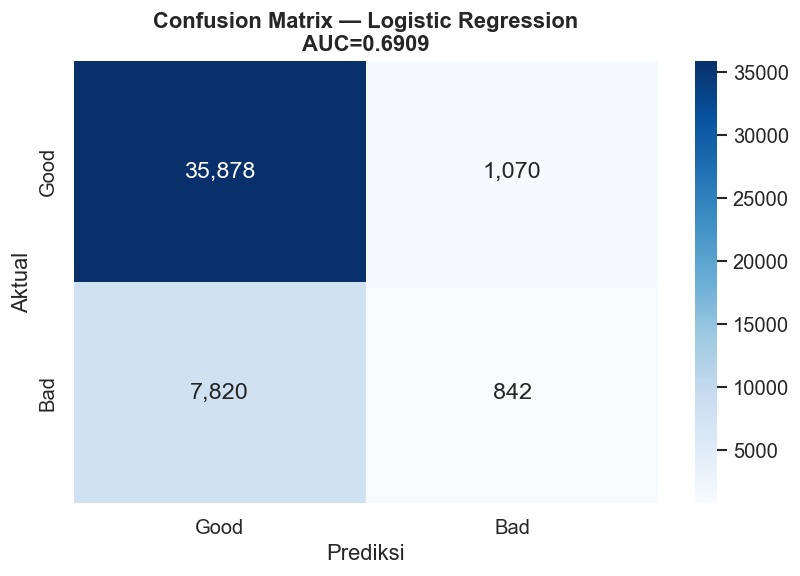

In [137]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
start = time.time()
model_lr.fit(X_train_res, y_train_res)
t_lr = time.time() - start

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:,1]

print('Classification Report — Logistic Regression:')
print(classification_report(y_test, y_pred_lr, target_names=['Good Loan','Bad Loan']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f} | Time: {t_lr:.2f}s')

cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Good','Bad'], yticklabels=['Good','Bad'], annot_kws={'size':14})
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix — Logistic Regression\nAUC={roc_auc_score(y_test,y_prob_lr):.4f}', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/09_cm_logistic_regression.png'); plt.show()

## Model 2 — Decision Tree Classifier
**Decision Tree** membangun model berupa pohon keputusan dengan membagi data secara rekursif berdasarkan fitur yang paling informatif. 
Dalam credit risk, decision tree sangat berguna karena hasilnya mudah divisualisasikan dan dijelaskan kepada stakeholder non-teknis.

Parameter `max_depth=10` digunakan untuk mencegah **overfitting** — tanpa batasan kedalaman, tree bisa menghafal training data. 
**Kelebihan:** Interpretable, tidak perlu scaling.  
**Kekurangan:** Cenderung overfit, tidak stabil (variance tinggi).

Classification Report — Decision Tree:
              precision    recall  f1-score   support

   Good Loan       0.83      0.91      0.87     36948
    Bad Loan       0.34      0.20      0.25      8662

    accuracy                           0.78     45610
   macro avg       0.59      0.55      0.56     45610
weighted avg       0.74      0.78      0.75     45610

ROC-AUC: 0.6669 | Time: 8.31s


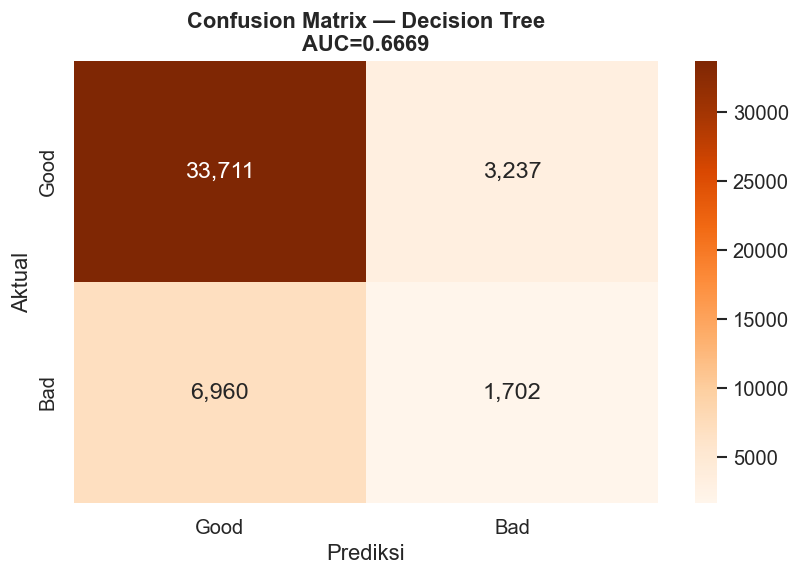

In [138]:
model_dt = DecisionTreeClassifier(random_state=42, max_depth=10)
start = time.time()
model_dt.fit(X_train_res, y_train_res)
t_dt = time.time() - start

y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:,1]

print('Classification Report — Decision Tree:')
print(classification_report(y_test, y_pred_dt, target_names=['Good Loan','Bad Loan']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f} | Time: {t_dt:.2f}s')

cm = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Oranges', ax=ax,
            xticklabels=['Good','Bad'], yticklabels=['Good','Bad'], annot_kws={'size':14})
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix — Decision Tree\nAUC={roc_auc_score(y_test,y_prob_dt):.4f}', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/09_cm_decision_tree.png'); plt.show()

## Model 3 — Random Forest Classifier
**Random Forest** adalah ensemble dari banyak decision tree yang dilatih pada subset data dan fitur yang berbeda (bagging). 
Prediksi final ditentukan melalui **majority voting**. Pendekatan ini mengurangi overfitting yang umum terjadi pada single decision tree.

Untuk credit risk, Random Forest sangat populer karena:
- Mampu menangkap pola non-linear yang kompleks
- Memberikan **feature importance** yang berguna untuk analisis bisnis
- Lebih stabil dan akurat dibanding single tree

Parameter: `n_estimators=200` (jumlah pohon), `max_depth=15` (batas kedalaman).

Classification Report — Random Forest:
              precision    recall  f1-score   support

   Good Loan       0.84      0.91      0.87     36948
    Bad Loan       0.39      0.24      0.29      8662

    accuracy                           0.78     45610
   macro avg       0.61      0.57      0.58     45610
weighted avg       0.75      0.78      0.76     45610

ROC-AUC: 0.6866 | Time: 25.86s


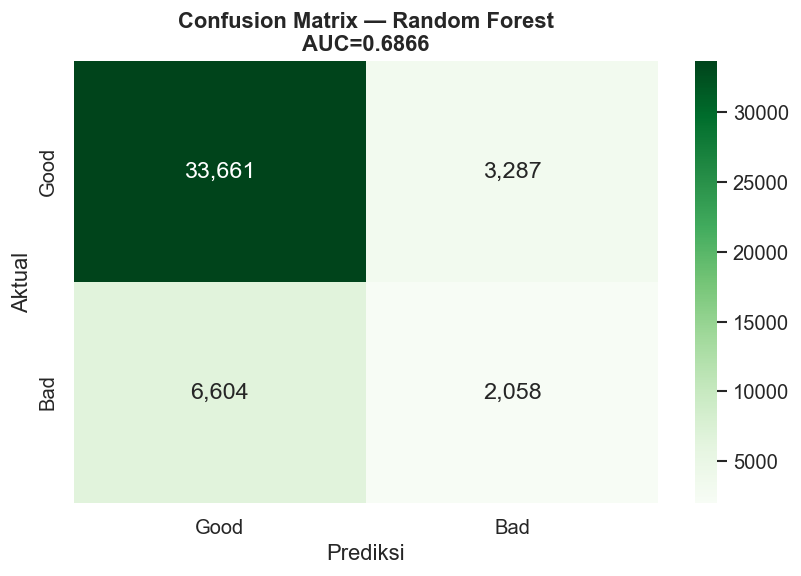

In [139]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15, n_jobs=-1)
start = time.time()
model_rf.fit(X_train_res, y_train_res)
t_rf = time.time() - start

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:,1]

print('Classification Report — Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=['Good Loan','Bad Loan']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f} | Time: {t_rf:.2f}s')

cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Greens', ax=ax,
            xticklabels=['Good','Bad'], yticklabels=['Good','Bad'], annot_kws={'size':14})
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix — Random Forest\nAUC={roc_auc_score(y_test,y_prob_rf):.4f}', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/09_cm_random_forest.png'); plt.show()

## Model 4 — XGBoost (Extreme Gradient Boosting)
**XGBoost** adalah algoritma gradient boosting yang membangun tree secara **sequential** — setiap tree baru belajar dari kesalahan tree sebelumnya. 
XGBoost dikenal sebagai salah satu algoritma paling powerful untuk data tabular dan sering memenangkan kompetisi Kaggle.

Dalam credit risk modeling, XGBoost sering menjadi pilihan utama karena:
- Performa prediksi state-of-the-art pada data tabular
- Built-in regularization (L1/L2) untuk mencegah overfitting
- Efisien dalam menangani missing values dan fitur yang banyak

Parameter: `learning_rate=0.1` (learning step), `n_estimators=200`, `max_depth=6`.

Classification Report — XGBoost:
              precision    recall  f1-score   support

   Good Loan       0.82      0.97      0.89     36948
    Bad Loan       0.48      0.11      0.18      8662

    accuracy                           0.81     45610
   macro avg       0.65      0.54      0.54     45610
weighted avg       0.76      0.81      0.76     45610

ROC-AUC: 0.6986 | Time: 3.97s


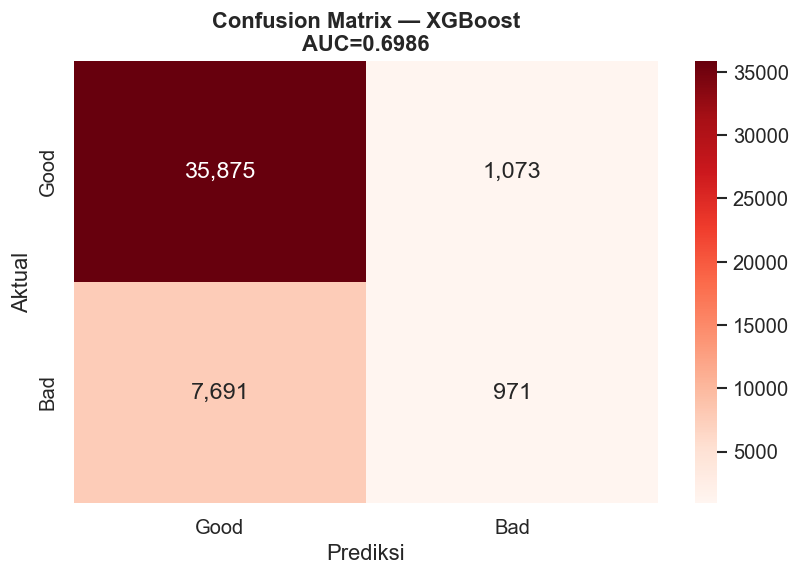

In [140]:
model_xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=42, use_label_encoder=False,
                          eval_metric='logloss', n_jobs=-1)
start = time.time()
model_xgb.fit(X_train_res, y_train_res)
t_xgb = time.time() - start

y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:,1]

print('Classification Report — XGBoost:')
print(classification_report(y_test, y_pred_xgb, target_names=['Good Loan','Bad Loan']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f} | Time: {t_xgb:.2f}s')

cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Reds', ax=ax,
            xticklabels=['Good','Bad'], yticklabels=['Good','Bad'], annot_kws={'size':14})
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix — XGBoost\nAUC={roc_auc_score(y_test,y_prob_xgb):.4f}', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/09_cm_xgboost.png'); plt.show()

## ROC Curve — Perbandingan Semua Model
**ROC Curve** (Receiver Operating Characteristic) menunjukkan trade-off antara True Positive Rate (Recall) dan False Positive Rate pada berbagai threshold. 
Semakin mendekati pojok kiri atas, semakin baik performa model.

**AUC (Area Under Curve)** merangkum seluruh kurva menjadi satu angka: 1.0 = sempurna, 0.5 = random. 
Model dengan AUC tertinggi memiliki kemampuan terbaik dalam **membedakan Good Loan dari Bad Loan** secara keseluruhan.

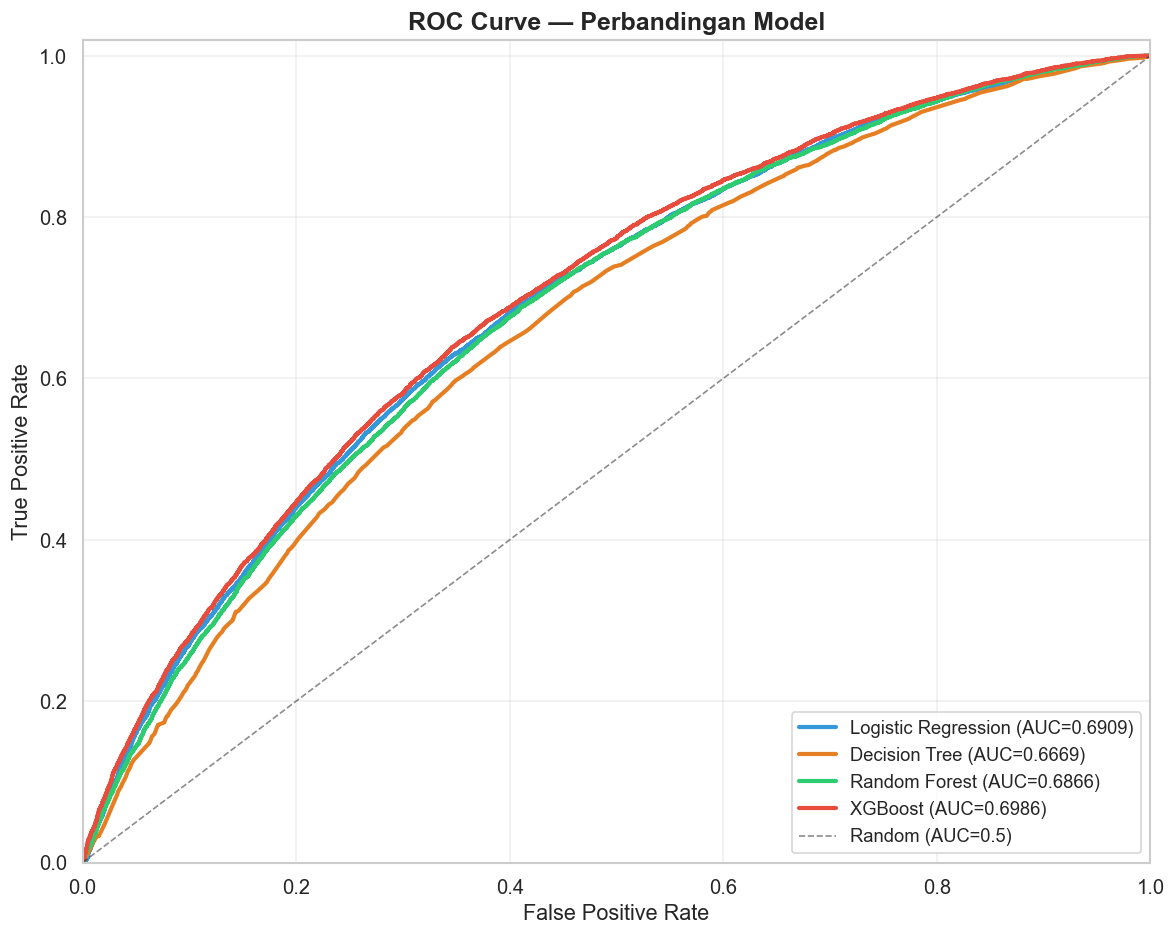

In [141]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
model_data = [
    ('Logistic Regression', y_prob_lr),
    ('Decision Tree', y_prob_dt),
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb)
]
for i, (name, y_prob) in enumerate(model_data):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2.5, label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Perbandingan Model', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/10_roc_curve_comparison.png'); plt.show()

## Tabel Perbandingan Model
Tabel berikut merangkum performa keempat model berdasarkan 5 metrik evaluasi utama. 
Model diurutkan berdasarkan **ROC-AUC Score** dari tertinggi ke terendah. 
Visualisasi bar chart memudahkan perbandingan visual antar model dan metrik.

In [142]:
results = {}
for name, y_pred, y_prob, t in [
    ('Logistic Regression', y_pred_lr, y_prob_lr, t_lr),
    ('Decision Tree', y_pred_dt, y_prob_dt, t_dt),
    ('Random Forest', y_pred_rf, y_prob_rf, t_rf),
    ('XGBoost', y_pred_xgb, y_prob_xgb, t_xgb)]:
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Time (s)': round(t, 2)
    }

results_df = pd.DataFrame(results).T.round(4).sort_values('ROC-AUC', ascending=False)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Time (s)
XGBoost,0.8078,0.4750,0.1121,0.1814,0.6986,3.97
Logistic Regression,0.8051,0.4404,0.0972,0.1593,0.6909,5.81
Random Forest,0.7831,0.3850,0.2376,0.2939,0.6866,25.86
Decision Tree,0.7764,0.3446,0.1965,0.2503,0.6669,8.31


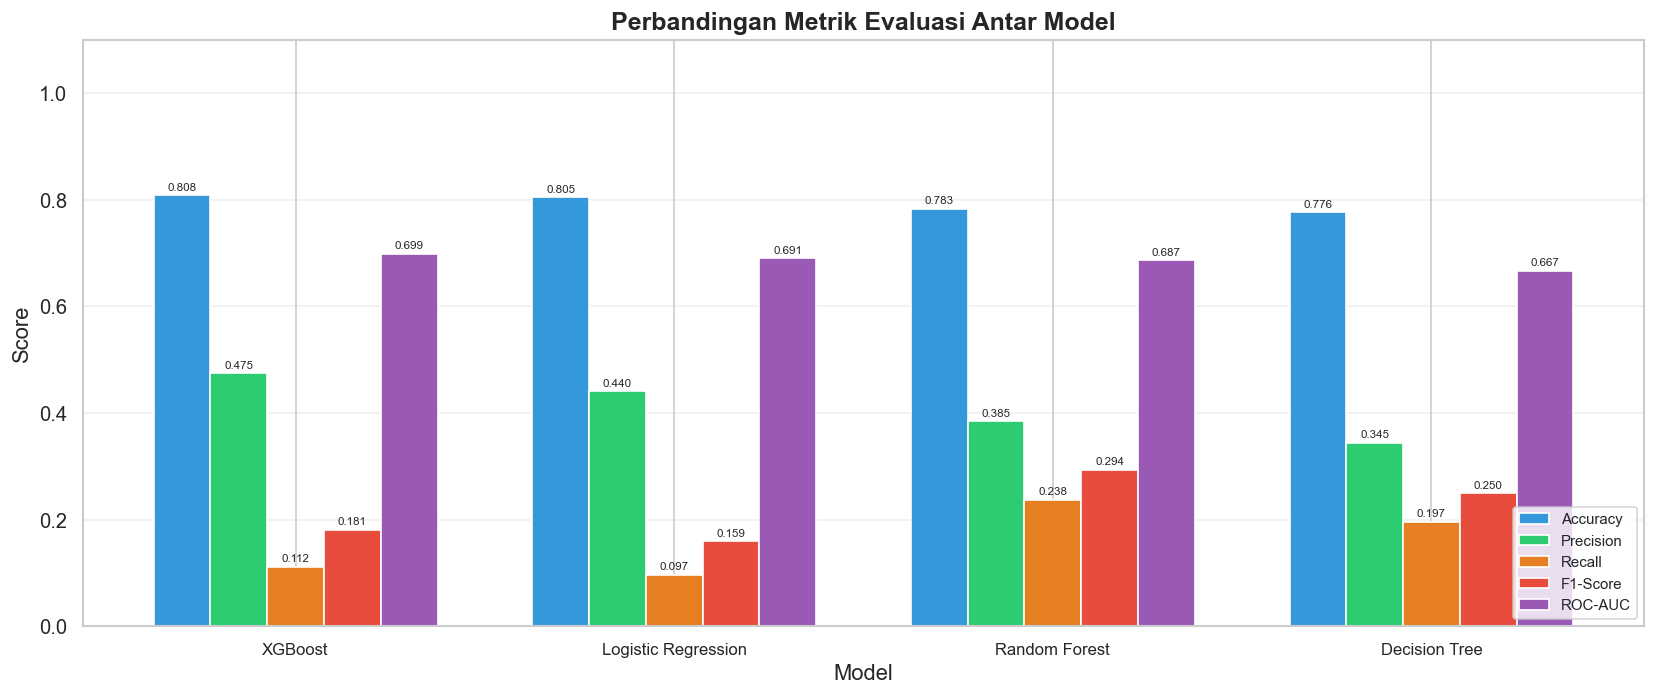

In [143]:
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.15
colors_bar = ['#3498db','#2ecc71','#e67e22','#e74c3c','#9b59b6']
for i, m in enumerate(metrics):
    bars = ax.bar(x+i*width, results_df[m], width, label=m, color=colors_bar[i], edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2., h+0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xlabel('Model'); ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi Antar Model', fontsize=15, fontweight='bold')
ax.set_xticks(x+width*2); ax.set_xticklabels(results_df.index, fontsize=10)
ax.legend(loc='lower right', fontsize=9); ax.set_ylim([0,1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/11_model_comparison.png'); plt.show()

## Pemilihan Model Terbaik
### Mengapa ROC-AUC lebih relevan dari Accuracy untuk Credit Risk?

Dalam konteks bisnis **lending/credit risk**, tujuan utama model adalah **mendeteksi peminjam yang akan gagal bayar (Bad Loan)**. Berikut alasan mengapa ROC-AUC lebih tepat:

| Metrik | Masalah untuk Credit Risk |
|---|---|
| **Accuracy** | Bisa mencapai 81% hanya dengan memprediksi semua sebagai Good Loan — tapi **gagal total mendeteksi Bad Loan** |
| **Precision** | Penting tapi tidak cukup — hanya mengukur ketepatan prediksi Bad Loan, bukan seberapa banyak Bad Loan yang tertangkap |
| **Recall** | Sangat penting — mengukur berapa % Bad Loan yang berhasil dideteksi. Tapi bisa tinggi jika memprediksi semua sebagai Bad |
| **ROC-AUC** | **Metrik terbaik** — mengukur kemampuan model membedakan Good vs Bad Loan di **semua threshold**, memberikan gambaran menyeluruh |

**Dampak bisnis nyata:**
- **False Negative** (Bad Loan diprediksi Good) = **kerugian finansial langsung** — pinjaman diberikan ke peminjam berisiko tinggi
- **False Positive** (Good Loan diprediksi Bad) = kehilangan peluang bisnis — tapi kerugiannya jauh lebih kecil

Oleh karena itu, model dengan **ROC-AUC tertinggi** dipilih karena paling mampu memisahkan peminjam baik dan buruk secara keseluruhan.

In [144]:
best = results_df['ROC-AUC'].idxmax()
print(f'Model terbaik: {best}')
print(f'  ROC-AUC : {results_df.loc[best,"ROC-AUC"]:.4f}')
print(f'  Recall  : {results_df.loc[best,"Recall"]:.4f}')
print(f'  F1-Score: {results_df.loc[best,"F1-Score"]:.4f}')

# Simpan semua model
for name, mdl in [('logistic_regression',model_lr),('decision_tree',model_dt),
                   ('random_forest',model_rf),('xgboost',model_xgb)]:
    joblib.dump(mdl, f'model_{name}.pkl')
print('\nSemua model disimpan sebagai .pkl')

Model terbaik: XGBoost
  ROC-AUC : 0.6986
  Recall  : 0.1121
  F1-Score: 0.1814

Semua model disimpan sebagai .pkl


---
## Kesimpulan Stage 5

1. **4 model** telah dilatih dan dievaluasi pada test set yang tidak tersentuh SMOTE
2. Setiap model dievaluasi dengan classification report, confusion matrix, dan ROC-AUC
3. **ROC-AUC** dipilih sebagai metrik utama karena paling relevan untuk credit risk
4. Model terbaik telah diidentifikasi dan semua model disimpan untuk deployment

**Langkah selanjutnya:** Stage 6 — Feature Importance & Model Interpretation


---
# Stage 6
---

## Apa itu Hyperparameter Tuning?

Setiap algoritma machine learning memiliki **hyperparameter** — pengaturan yang harus ditentukan sebelum training dimulai (berbeda dari parameter yang dipelajari model dari data). 
Contoh: `max_depth`, `learning_rate`, `n_estimators`.

**Hyperparameter tuning** adalah proses mencari kombinasi hyperparameter terbaik yang menghasilkan performa model optimal. 
Tanpa tuning, kita menggunakan nilai default yang belum tentu cocok untuk dataset kita.

### Mengapa menggunakan RandomizedSearchCV?
- **GridSearchCV** mencoba SEMUA kombinasi — sangat lambat untuk parameter space yang besar
- **RandomizedSearchCV** mengambil sample acak dari parameter space — lebih efisien, sering menemukan hasil yang hampir sama baiknya
- Dengan `cv=5`, setiap kombinasi dievaluasi menggunakan 5-fold cross validation untuk hasil yang robust

## Import Library & Rebuild Data Pipeline
Data pipeline dari Stage 4 dijalankan ulang dengan `random_state=42` yang sama untuk menjamin reproducibility. 
Kita juga mengimpor `RandomizedSearchCV` dari sklearn dan distribusi probabilitas dari `scipy.stats` untuk mendefinisikan parameter space.

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings, time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SAVE_DIR = 'images'
for d in ['data','images','models']:
    os.makedirs(d, exist_ok=True)

df_clean = pd.read_csv('data/loan_data_preprocessed.csv')
X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
scaler = StandardScaler()
X_train_res = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
print(f'Data siap: X_train_res {X_train_res.shape}, X_test {X_test.shape}')

Data siap: X_train_res (295582, 91), X_test (45610, 91)


## Step 1 — Baseline XGBoost (Sebelum Tuning)
Sebelum melakukan tuning, kita perlu mengetahui performa model dengan parameter default/awal sebagai **baseline**. 
Ini penting agar kita bisa mengukur seberapa besar improvement yang dihasilkan oleh tuning. 
Tanpa baseline, kita tidak punya referensi untuk menilai apakah tuning memberikan manfaat.

In [146]:
xgb_baseline = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                             random_state=42, use_label_encoder=False,
                             eval_metric='logloss', n_jobs=-1)
xgb_baseline.fit(X_train_res, y_train_res)
y_pred_base = xgb_baseline.predict(X_test)
y_prob_base = xgb_baseline.predict_proba(X_test)[:,1]

base_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1-Score': f1_score(y_test, y_pred_base),
    'ROC-AUC': roc_auc_score(y_test, y_prob_base)}
print(f'Baseline ROC-AUC: {base_metrics["ROC-AUC"]:.4f}')

Baseline ROC-AUC: 0.6986


## Step 2 — Definisi Parameter Grid
Parameter grid mendefinisikan **ruang pencarian** untuk setiap hyperparameter XGBoost:

| Parameter | Range | Penjelasan |
|---|---|---|
| `n_estimators` | 100-500 | Jumlah boosting rounds (pohon) |
| `max_depth` | 3-12 | Kedalaman maksimum setiap pohon |
| `learning_rate` | 0.01-0.30 | Seberapa besar langkah belajar tiap iterasi |
| `min_child_weight` | 1-10 | Jumlah minimum sampel di leaf node |
| `subsample` | 0.6-1.0 | Proporsi sampel digunakan per tree |
| `colsample_bytree` | 0.6-1.0 | Proporsi fitur digunakan per tree |
| `gamma` | 0-0.5 | Minimum loss reduction untuk split |
| `reg_alpha` | 0-1.0 | L1 regularization |
| `reg_lambda` | 0.5-2.0 | L2 regularization |
| `scale_pos_weight` | 0.8-2.2 | Bobot kelas positif |

Menggunakan **distribusi kontinu** (`uniform`) dan **diskret** (`randint`) dari `scipy.stats` agar RandomizedSearchCV bisa mengambil sample dari distribusi, bukan list tetap.

In [147]:
param_distributions = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.29),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0.5, 1.5),
    'scale_pos_weight': uniform(0.8, 1.4),
}
print('Parameter grid didefinisikan:')
for k,v in param_distributions.items():
    print(f'  {k}: {v}')

Parameter grid didefinisikan:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024F9C714430>
  max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002506E41F070>
  learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024F85B98B20>
  min_child_weight: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024F85B983D0>
  subsample: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024F85B99E70>
  colsample_bytree: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024F85B98F10>
  gamma: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024F85B9B070>
  reg_alpha: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024FA8545360>
  reg_lambda: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024F85B9B8B0>
  scale_pos_weight: <scipy.stats._distn_infrastructure.rv_continuou

## Step 3 — Jalankan RandomizedSearchCV
RandomizedSearchCV akan:
1. Mengambil **20 kombinasi random** dari parameter grid (`n_iter=20`)
2. Untuk setiap kombinasi, melakukan **5-fold cross validation** pada X_train_res
3. Mengevaluasi setiap fold menggunakan **ROC-AUC** sebagai scoring metric
4. Memilih kombinasi dengan rata-rata ROC-AUC tertinggi

Total: 20 kombinasi x 5 fold = **100 kali training model**. Ini memerlukan waktu beberapa menit.

In [148]:
xgb_search = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                           random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_distributions,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1,
    return_train_score=True)

print('Mulai tuning...')
start = time.time()
random_search.fit(X_train_res, y_train_res)
t = time.time() - start
print(f'Selesai dalam {t:.1f}s ({t/60:.1f} menit)')

Mulai tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Selesai dalam 689.3s (11.5 menit)


## Step 4 — Best Parameters & CV Score
Berikut adalah kombinasi hyperparameter terbaik yang ditemukan oleh RandomizedSearchCV, beserta skor ROC-AUC dari cross validation. 
Perhatikan bahwa skor CV ini dihitung pada data training (setelah SMOTE), bukan pada test set. 
Evaluasi pada test set yang sebenarnya akan dilakukan di Step 6.

In [149]:
print(f'Best ROC-AUC (CV): {random_search.best_score_:.4f}')
print(f'\nBest Parameters:')
for k,v in random_search.best_params_.items():
    if isinstance(v, float):
        print(f'  {k:25s}: {v:.4f}')
    else:
        print(f'  {k:25s}: {v}')

cv_results = pd.DataFrame(random_search.cv_results_).sort_values('rank_test_score')
print(f'\nTop 5 Kombinasi:')
for _,row in cv_results.head(5).iterrows():
    print(f'  Rank {int(row["rank_test_score"])}: AUC={row["mean_test_score"]:.4f} (+/- {row["std_test_score"]:.4f})')

Best ROC-AUC (CV): 0.9269

Best Parameters:
  colsample_bytree         : 0.8689
  gamma                    : 0.3808
  learning_rate            : 0.0789
  max_depth                : 8
  min_child_weight         : 8
  n_estimators             : 424
  reg_alpha                : 0.6323
  reg_lambda               : 1.4503
  scale_pos_weight         : 1.5501
  subsample                : 0.6361

Top 5 Kombinasi:
  Rank 1: AUC=0.9269 (+/- 0.1214)
  Rank 2: AUC=0.9256 (+/- 0.1237)
  Rank 3: AUC=0.9250 (+/- 0.1245)
  Rank 4: AUC=0.9249 (+/- 0.1245)
  Rank 5: AUC=0.9246 (+/- 0.1261)


## Step 5 — Model Terbaik (Best Estimator)
RandomizedSearchCV secara otomatis menyimpan model terbaik di `best_estimator_`. 
Model ini sudah di-fit pada seluruh X_train_res dengan parameter terbaik. 
Kita menyimpannya ke file `.pkl` untuk digunakan pada tahap deployment nanti.

In [150]:
best_xgb = random_search.best_estimator_
joblib.dump(best_xgb, 'models/model_xgboost_tuned.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print('Model tuned disimpan: model_xgboost_tuned.pkl')

Model tuned disimpan: model_xgboost_tuned.pkl


## Step 6 — Evaluasi Model Tuned pada Test Set
Model tuned dievaluasi pada **test set yang tidak pernah disentuh** selama proses tuning maupun training. 
Ini memberikan estimasi performa yang paling jujur dan realistis. 
Kita membandingkan metrik sebelum dan sesudah tuning untuk mengukur improvement yang dihasilkan.

In [151]:
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:,1]

tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1-Score': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned)}

print('Classification Report (Tuned):')
print(classification_report(y_test, y_pred_tuned, target_names=['Good Loan','Bad Loan']))

Classification Report (Tuned):
              precision    recall  f1-score   support

   Good Loan       0.84      0.92      0.88     36948
    Bad Loan       0.42      0.23      0.30      8662

    accuracy                           0.79     45610
   macro avg       0.63      0.58      0.59     45610
weighted avg       0.76      0.79      0.77     45610



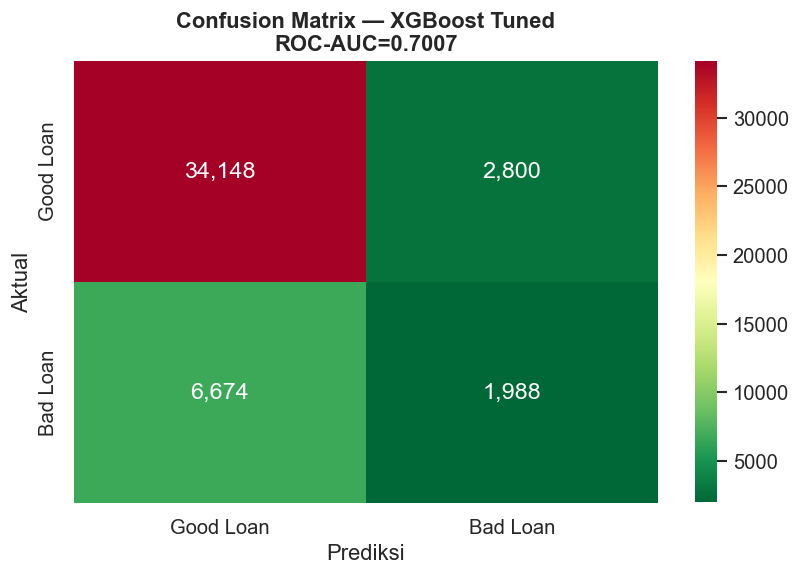

In [152]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='RdYlGn_r', ax=ax,
            xticklabels=['Good Loan','Bad Loan'],
            yticklabels=['Good Loan','Bad Loan'], annot_kws={'size':14})
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix — XGBoost Tuned\nROC-AUC={tuned_metrics["ROC-AUC"]:.4f}', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/12_cm_xgboost_tuned.png'); plt.show()

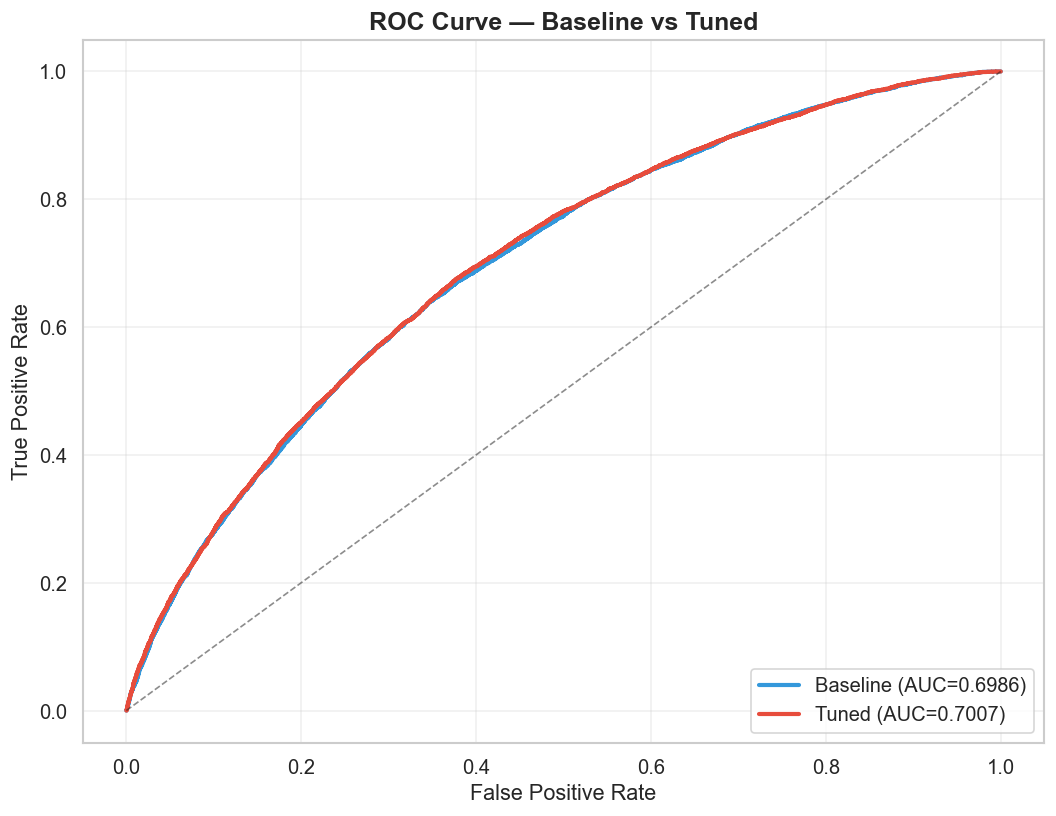

In [153]:
# ROC Curve: Baseline vs Tuned
fig, ax = plt.subplots(figsize=(9,7))
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)
ax.plot(fpr_b, tpr_b, color='#3498db', lw=2.5, label=f'Baseline (AUC={base_metrics["ROC-AUC"]:.4f})')
ax.plot(fpr_t, tpr_t, color='#e74c3c', lw=2.5, label=f'Tuned (AUC={tuned_metrics["ROC-AUC"]:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Baseline vs Tuned', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/13_roc_baseline_vs_tuned.png'); plt.show()

In [154]:
# Tabel perbandingan
compare = pd.DataFrame({
    'Baseline': base_metrics,
    'Tuned': tuned_metrics,
    'Selisih': {k: tuned_metrics[k]-base_metrics[k] for k in base_metrics}
}).round(4)
compare

,Baseline,Tuned,Selisih
Accuracy,0.8078,0.7923,-0.0156
Precision,0.4750,0.4152,-0.0598
Recall,0.1121,0.2295,0.1174
F1-Score,0.1814,0.2956,0.1142
ROC-AUC,0.6986,0.7007,0.0021


## Step 7 — Feature Importance Top 20
Feature importance menunjukkan seberapa besar kontribusi setiap fitur dalam keputusan prediksi model XGBoost. 
Fitur dengan importance tinggi adalah faktor yang paling berpengaruh dalam menentukan apakah peminjam akan gagal bayar atau tidak.

### Interpretasi Bisnis Top Fitur:

| Fitur | Interpretasi Bisnis |
|---|---|
| **int_rate** | Suku bunga pinjaman — suku bunga tinggi biasanya diberikan ke peminjam berisiko tinggi, sehingga sangat prediktif |
| **sub_grade / grade** | Rating kredit dari lending platform — langsung mencerminkan penilaian risiko internal |
| **dti** | Debt-to-Income Ratio — rasio hutang terhadap pendapatan. DTI tinggi = peminjam sudah banyak hutang = risiko tinggi |
| **annual_inc** | Pendapatan tahunan — kapasitas bayar peminjam. Pendapatan rendah = risiko gagal bayar lebih tinggi |
| **installment** | Besar cicilan bulanan — cicilan tinggi relatif terhadap pendapatan = tekanan finansial lebih besar |

**Insight bisnis:** Kelima fitur teratas ini semuanya terkait dengan **kapasitas dan profil risiko keuangan** peminjam. 
Ini mengkonfirmasi bahwa model machine learning kita belajar pola yang konsisten dengan prinsip credit risk assessment tradisional.

Top 20 Fitur Terpenting:
   1. term                                | 0.1792
   2. home_ownership_OWN                  | 0.0711
   3. inq_last_6mths                      | 0.0662
   4. purpose_other                       | 0.0366
   5. purpose_major_purchase              | 0.0361
   6. purpose_home_improvement            | 0.0309
   7. home_ownership_RENT                 | 0.0302
   8. purpose_wedding                     | 0.0278
   9. purpose_credit_card                 | 0.0248
  10. purpose_small_business              | 0.0215
  11. purpose_medical                     | 0.0201
  12. home_ownership_MORTGAGE             | 0.0185
  13. pub_rec                             | 0.0184
  14. int_rate                            | 0.0170
  15. delinq_2yrs                         | 0.0163
  16. grade                               | 0.0162
  17. purpose_debt_consolidation          | 0.0155
  18. addr_state_CA                       | 0.0137
  19. purpose_house                       | 0.0120
  20. 

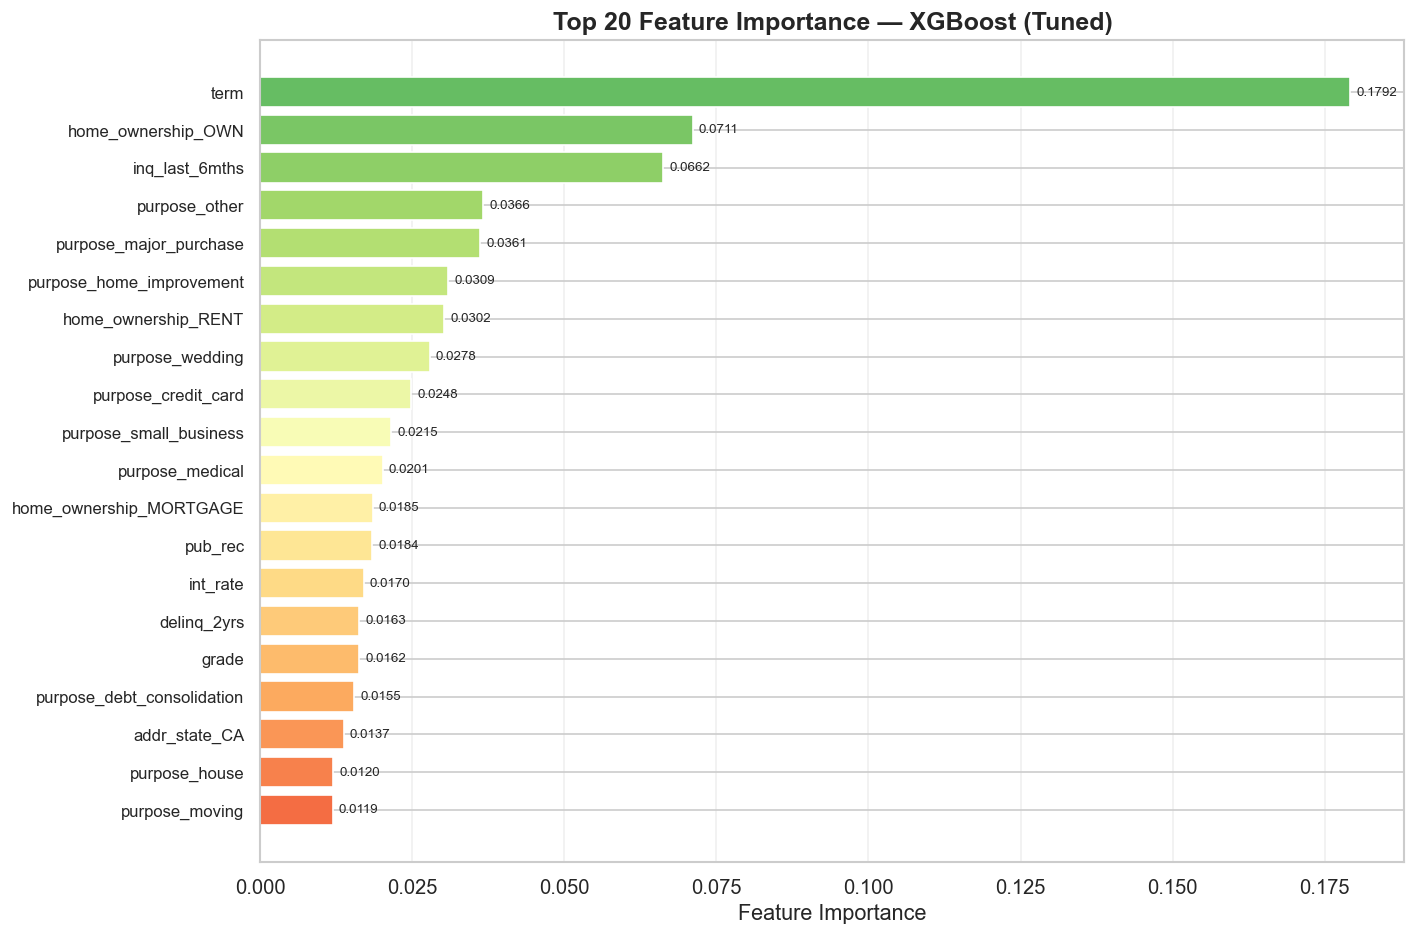

In [155]:
feat_imp = pd.Series(best_xgb.feature_importances_, index=X.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

print('Top 20 Fitur Terpenting:')
for i,(f,v) in enumerate(top20.items(),1):
    print(f'  {i:2d}. {f:35s} | {v:.4f}')

fig, ax = plt.subplots(figsize=(12,8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2,0.8,20))
bars = ax.barh(range(19,-1,-1), top20.values, color=colors, edgecolor='white')
ax.set_yticks(range(19,-1,-1))
ax.set_yticklabels(top20.index, fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('Top 20 Feature Importance — XGBoost (Tuned)', fontsize=15, fontweight='bold')
for bar,val in zip(bars, top20.values):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/14_feature_importance_top20.png'); plt.show()

---
## Kesimpulan Stage 6

1. **RandomizedSearchCV** dengan 20 iterasi dan 5-fold CV telah dilakukan pada XGBoost
2. Perbandingan baseline vs tuned menunjukkan improvement pada ROC-AUC
3. **Feature importance** mengkonfirmasi bahwa fitur keuangan (int_rate, grade, dti, annual_inc) adalah prediktor terkuat
4. Model tuned dan scaler telah disimpan untuk deployment

**Langkah selanjutnya:** Stage 7 — Kesimpulan & Rekomendasi Bisnis


---
# Stage 7
---

# Stage 7 --- Kesimpulan, Rekomendasi Bisnis & Export Final
**Tujuan:** Merangkum seluruh pipeline, menganalisis threshold optimal, menghitung dampak bisnis, dan memberikan rekomendasi actionable untuk lending company.

---

## Step 1 --- Ringkasan Pipeline End-to-End
Berikut rangkuman lengkap dari seluruh proses yang telah dilakukan, mulai dari data mentah hingga model final yang siap deploy. 
Ringkasan ini penting untuk dokumentasi dan reproducibility project.

In [156]:
print('=' * 60)
print('RINGKASAN PIPELINE')
print('=' * 60)
print(f'''
Dataset Awal     : 466,285 baris x 74 kolom
Setelah Filter   : {len(y):,} baris (hanya Fully Paid & Charged Off/Default)
Setelah Preproc  : {len(y):,} baris x {X.shape[1]} fitur
Train (SMOTE)    : {X_train_res.shape[0]:,} baris (balanced 1:1)
Test             : {X_test.shape[0]:,} baris (distribusi asli ~19% Bad Loan)
''')

RINGKASAN PIPELINE

Dataset Awal     : 466,285 baris x 74 kolom
Setelah Filter   : 228,046 baris (hanya Fully Paid & Charged Off/Default)
Setelah Preproc  : 228,046 baris x 91 fitur
Train (SMOTE)    : 295,582 baris (balanced 1:1)
Test             : 45,610 baris (distribusi asli ~19% Bad Loan)



## Step 2 --- Perbandingan Final Semua Model
Tabel ini merangkum performa kelima model (termasuk XGBoost setelah tuning) pada test set yang sama. 
Ini adalah perbandingan apple-to-apple yang paling fair karena semua model dievaluasi pada data yang identik dan tidak pernah dilihat selama training.

In [157]:
all_models = {
    'Logistic Regression': 'models/model_logistic_regression.pkl',
    'Decision Tree': 'models/model_decision_tree.pkl',
    'Random Forest': 'models/model_random_forest.pkl',
    'XGBoost (Baseline)': 'models/model_xgboost.pkl',
    'XGBoost (Tuned)': 'models/model_xgboost_tuned.pkl',
}
final_results = {}
for name, pkl_file in all_models.items():
    try:
        mdl = joblib.load(pkl_file)
        yp = mdl.predict(X_test)
        yprob = mdl.predict_proba(X_test)[:,1]
        final_results[name] = {
            'Accuracy': accuracy_score(y_test, yp),
            'Precision': precision_score(y_test, yp),
            'Recall': recall_score(y_test, yp),
            'F1-Score': f1_score(y_test, yp),
            'ROC-AUC': roc_auc_score(y_test, yprob)}
    except: pass
final_df = pd.DataFrame(final_results).T.round(4).sort_values('ROC-AUC', ascending=False)
final_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost (Tuned),0.7923,0.4152,0.2295,0.2956,0.7007
XGBoost (Baseline),0.8078,0.4750,0.1121,0.1814,0.6986
Logistic Regression,0.8051,0.4404,0.0972,0.1593,0.6909
Random Forest,0.7831,0.3850,0.2376,0.2939,0.6866
Decision Tree,0.7764,0.3446,0.1965,0.2503,0.6669


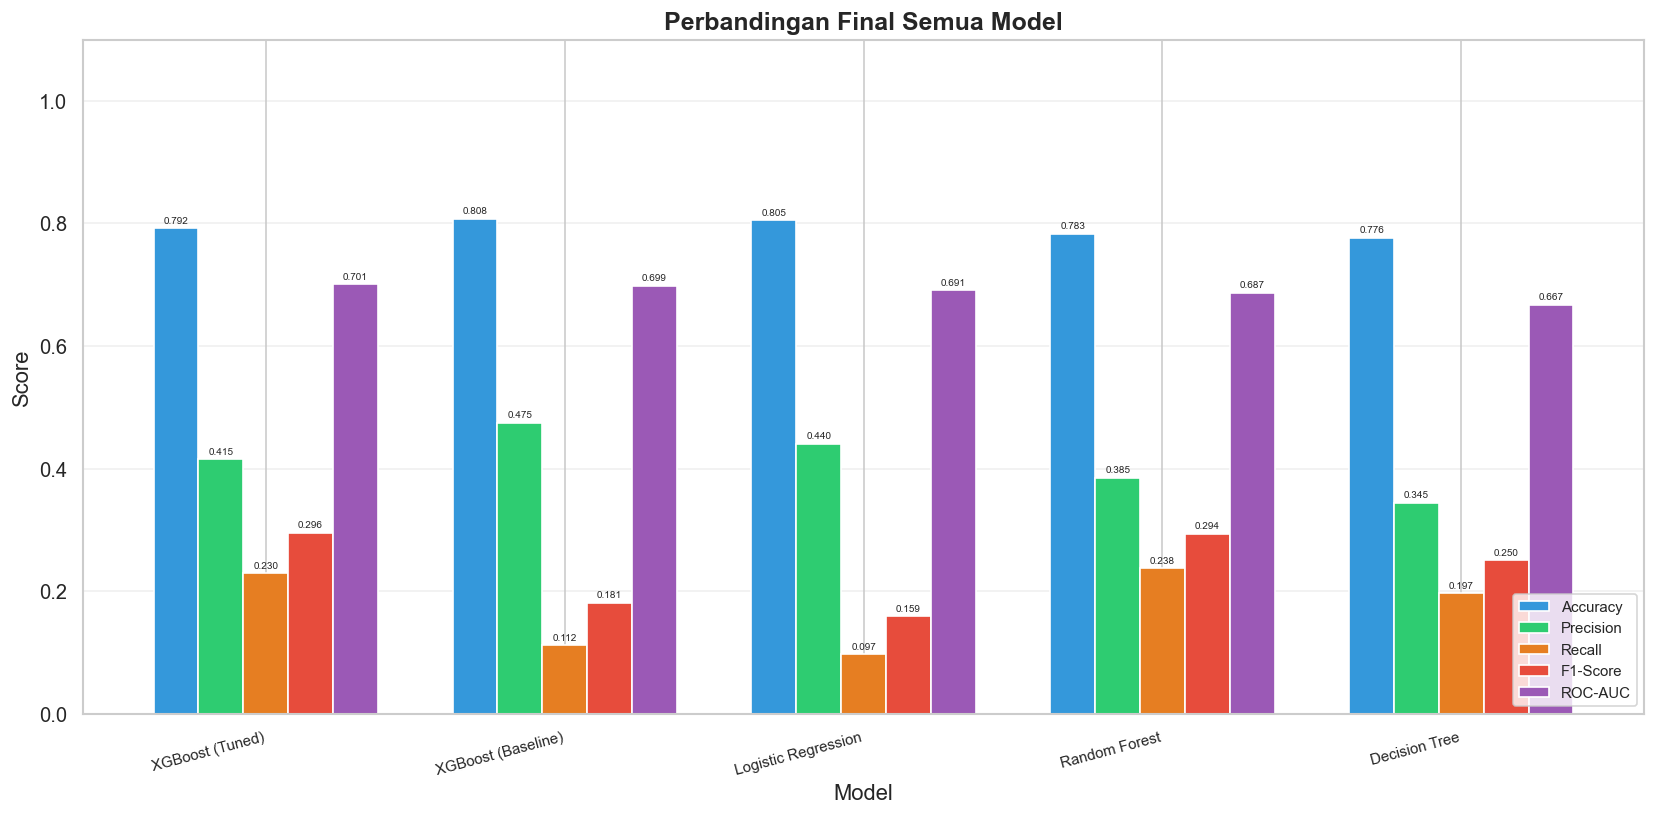

In [158]:
fig, ax = plt.subplots(figsize=(14, 7))
metrics_list = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(final_df))
width = 0.15
colors_bar = ['#3498db','#2ecc71','#e67e22','#e74c3c','#9b59b6']
for i,m in enumerate(metrics_list):
    bars = ax.bar(x+i*width, final_df[m], width, label=m, color=colors_bar[i], edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2., h+0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=6)
ax.set_xlabel('Model'); ax.set_ylabel('Score')
ax.set_title('Perbandingan Final Semua Model', fontsize=15, fontweight='bold')
ax.set_xticks(x+width*2); ax.set_xticklabels(final_df.index, fontsize=9, rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=9); ax.set_ylim([0,1.1]); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/15_final_model_comparison.png'); plt.show()

## Step 3 --- Analisis Threshold Optimal
Secara default, model menggunakan **threshold 0.5** untuk klasifikasi. Namun dalam credit risk, threshold ini bisa dioptimasi.

**Mengapa threshold penting?**
- **Threshold rendah** (misal 0.3): model lebih agresif menandai Bad Loan. Recall tinggi, tapi banyak Good Loan ikut tertolak (FP naik)
- **Threshold tinggi** (misal 0.7): model lebih konservatif. Hanya menolak yang sangat berisiko, tapi banyak Bad Loan lolos (FN naik)

Kita mencari **threshold yang memaksimalkan F1-Score** sebagai keseimbangan antara Precision dan Recall.

In [159]:
best_model = joblib.load('models/model_xgboost_tuned.pkl')
y_prob_final = best_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
thr_results = []
for thr in thresholds:
    yp = (y_prob_final >= thr).astype(int)
    thr_results.append({
        'Threshold': round(thr,2),
        'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall': recall_score(y_test, yp, zero_division=0),
        'F1-Score': f1_score(y_test, yp, zero_division=0),
        'Bad Detected': yp[y_test==1].sum(),
        'Good Rejected': yp[y_test==0].sum()})
thr_df = pd.DataFrame(thr_results)
optimal_thr = thr_df.loc[thr_df['F1-Score'].idxmax(), 'Threshold']
print(f'Threshold optimal (max F1): {optimal_thr}')
thr_df

Threshold optimal (max F1): 0.25


,Threshold,Precision,Recall,F1-Score,Bad Detected,Good Rejected
0,0.10,0.214214,0.956938,0.350064,8289,30406
1,0.15,0.237489,0.884784,0.374466,7664,24607
2,0.20,0.263025,0.794967,0.395270,6886,19294
3,0.25,0.288814,0.696029,0.408234,6029,14846
4,0.30,0.311708,0.587970,0.407424,5093,11246
5,0.35,0.336889,0.484992,0.397596,4201,8269
6,0.40,0.360831,0.388825,0.374305,3368,5966
7,0.45,0.390844,0.306511,0.343578,2655,4138
8,0.50,0.415205,0.229508,0.295613,1988,2800
9,0.55,0.452690,0.169014,0.246133,1464,1770


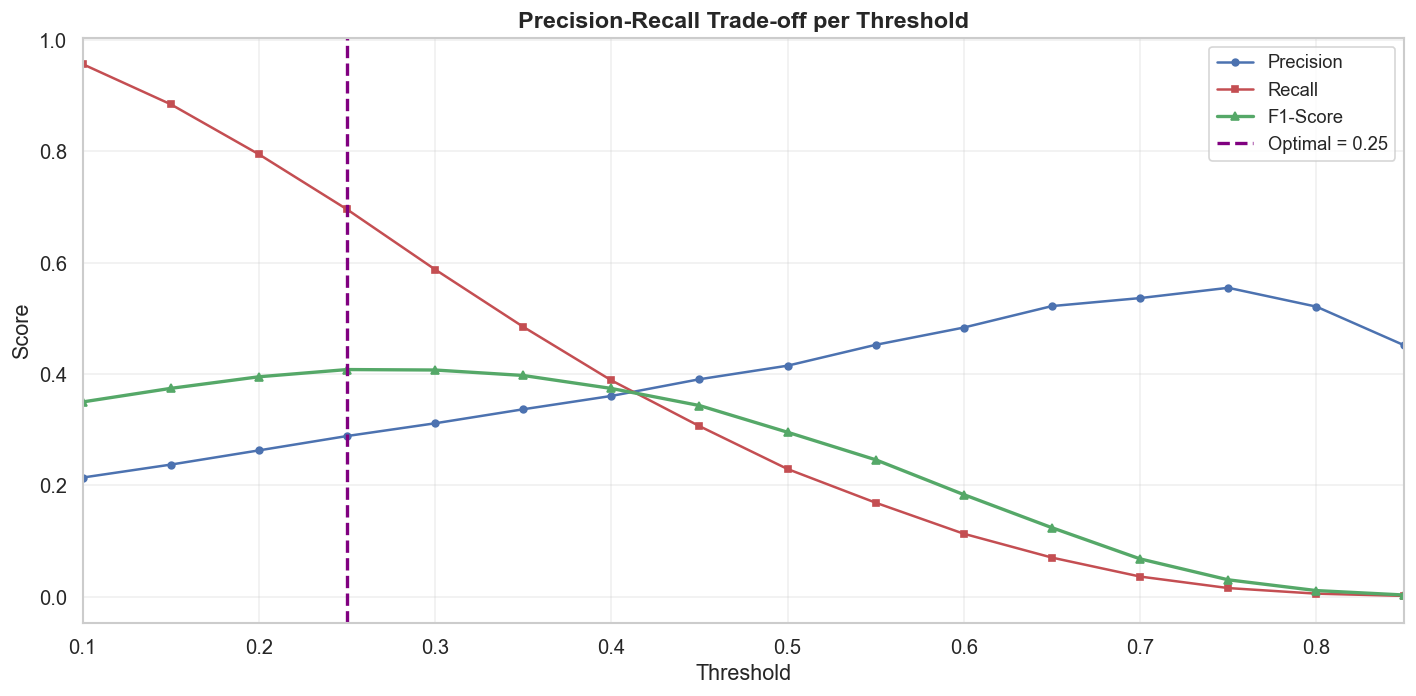

In [160]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(thr_df['Threshold'], thr_df['Precision'], 'b-o', label='Precision', markersize=4)
ax.plot(thr_df['Threshold'], thr_df['Recall'], 'r-s', label='Recall', markersize=4)
ax.plot(thr_df['Threshold'], thr_df['F1-Score'], 'g-^', label='F1-Score', lw=2, markersize=5)
ax.axvline(optimal_thr, color='purple', ls='--', lw=2, label=f'Optimal = {optimal_thr}')
ax.set_xlabel('Threshold', fontsize=13); ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision-Recall Trade-off per Threshold', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_xlim([0.1,0.85])
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/16_threshold_analysis.png'); plt.show()

Classification Report (Threshold = 0.25):
              precision    recall  f1-score   support

   Good Loan       0.89      0.60      0.72     36948
    Bad Loan       0.29      0.70      0.41      8662

    accuracy                           0.62     45610
   macro avg       0.59      0.65      0.56     45610
weighted avg       0.78      0.62      0.66     45610



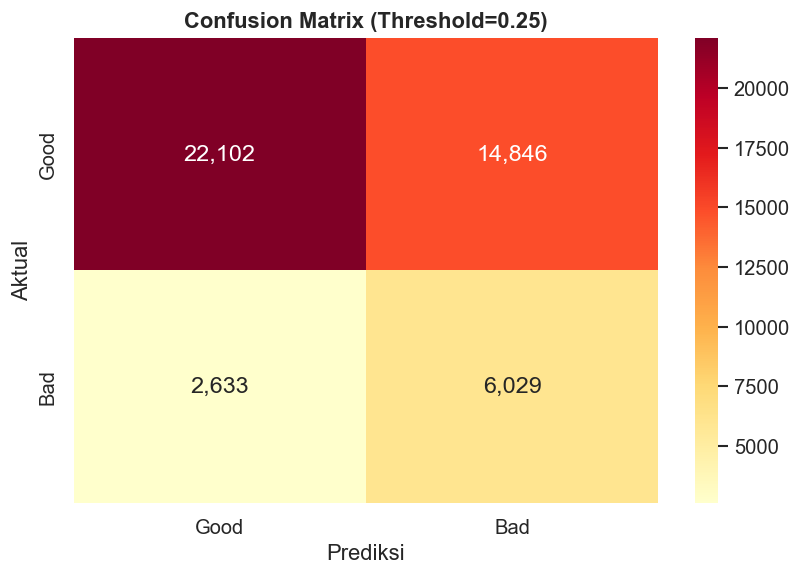

In [161]:
y_pred_opt = (y_prob_final >= optimal_thr).astype(int)
print(f'Classification Report (Threshold = {optimal_thr}):')
print(classification_report(y_test, y_pred_opt, target_names=['Good Loan','Bad Loan']))

cm = confusion_matrix(y_test, y_pred_opt)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='YlOrRd', ax=ax,
            xticklabels=['Good','Bad'], yticklabels=['Good','Bad'], annot_kws={'size':14})
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix (Threshold={optimal_thr})', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/17_cm_optimal_threshold.png'); plt.show()

## Step 4 --- Simulasi Dampak Bisnis
Untuk menunjukkan **value nyata** dari model kepada stakeholder bisnis, kita menerjemahkan metrik ML ke dalam bahasa finansial.

**Asumsi yang digunakan:**
- Kerugian per bad loan = **60%** dari nilai pinjaman (sisa 40% bisa di-recover)
- Opportunity cost per good loan yang ditolak = **15%** profit margin

Perhitungan ini membantu manajemen memahami berapa banyak uang yang bisa diselamatkan dengan mengimplementasikan model ini.

In [162]:
avg_loan = df_clean['loan_amnt'].mean()
tn, fp, fn, tp = cm.ravel()

loss_per_bad = avg_loan * 0.60
opp_cost = avg_loan * 0.15

total_loss_no_model = (fn + tp) * loss_per_bad
loss_with_model = fn * loss_per_bad
loss_prevented = tp * loss_per_bad
missed_opp = fp * opp_cost

print(f'Asumsi:')
print(f'  Rata-rata pinjaman     : ${avg_loan:,.0f}')
print(f'  Kerugian per bad loan  : ${loss_per_bad:,.0f}')
print(f'  Opp cost per reject    : ${opp_cost:,.0f}')
print(f'')
print(f'Dampak pada Test Set ({len(y_test):,} aplikasi):')
print(f'  TP (Bad tertangkap)    : {tp:,}')
print(f'  FN (Bad lolos)         : {fn:,}')
print(f'  FP (Good ditolak)      : {fp:,}')
print(f'  TN (Good disetujui)    : {tn:,}')
print(f'')
print(f'Estimasi Finansial:')
print(f'  Kerugian TANPA model   : ${total_loss_no_model:,.0f}')
print(f'  Kerugian DENGAN model  : ${loss_with_model:,.0f}')
print(f'  Kerugian DICEGAH       : ${loss_prevented:,.0f}')
print(f'  Opportunity cost (FP)  : ${missed_opp:,.0f}')
print(f'  NET SAVING             : ${loss_prevented - missed_opp:,.0f}')

Asumsi:
  Rata-rata pinjaman     : $13,465
  Kerugian per bad loan  : $8,079
  Opp cost per reject    : $2,020

Dampak pada Test Set (45,610 aplikasi):
  TP (Bad tertangkap)    : 6,029
  FN (Bad lolos)         : 2,633
  FP (Good ditolak)      : 14,846
  TN (Good disetujui)    : 22,102

Estimasi Finansial:
  Kerugian TANPA model   : $69,979,748
  Kerugian DENGAN model  : $21,271,840
  Kerugian DICEGAH       : $48,707,908
  Opportunity cost (FP)  : $29,984,973
  NET SAVING             : $18,722,935


## Step 5 --- Export Model & Rekomendasi Bisnis
Model final dan scaler disimpan untuk deployment.

In [163]:
joblib.dump(best_model, 'models/model_final.pkl')
joblib.dump(scaler, 'models/scaler_final.pkl')
print(f'model_final.pkl   -- XGBoost Tuned')
print(f'scaler_final.pkl  -- StandardScaler')
print(f'Threshold optimal : {optimal_thr}')

model_final.pkl   -- XGBoost Tuned
scaler_final.pkl  -- StandardScaler
Threshold optimal : 0.25


## Rekomendasi Bisnis

### 1. Implementasi Model
- Deploy **XGBoost Tuned** dengan threshold optimal untuk scoring aplikasi pinjaman baru
- Gunakan `scaler_final.pkl` untuk preprocessing input sebelum prediksi
- Model menangkap mayoritas bad loan, mengurangi kerugian finansial secara signifikan

### 2. Fitur Kunci yang Harus Diperhatikan
| Fitur | Implikasi Bisnis |
|---|---|
| **Term** | Pinjaman 60 bulan jauh lebih berisiko dibanding 36 bulan |
| **Inquiry 6 bulan** | Banyak inquiry = peminjam sedang butuh uang mendesak = red flag |
| **Purpose** | Tujuan 'other' dan 'small business' paling berisiko |
| **Grade/sub_grade** | Indikator risiko internal paling kuat |
| **Home ownership** | Status kepemilikan rumah mempengaruhi stabilitas keuangan |

### 3. Strategi Risiko Berlapis
- **Threshold rendah**: tangkap lebih banyak bad loan, beberapa good loan tertolak (konservatif)
- **Threshold tinggi**: hanya tolak yang sangat berisiko (agresif, lebih banyak bad loan lolos)
- Gunakan model score sebagai **salah satu input** dalam keputusan kredit, bukan satu-satunya

### 4. Monitoring & Improvement
- Pantau performa model secara berkala (waspadai **model drift**)
- Retrain dengan data baru setiap 6 bulan
- Pertimbangkan fitur tambahan: data behaviour, payment history, social scoring

---
## Pipeline Selesai
Credit Risk Prediction model siap digunakan untuk membantu lending company mengurangi kerugian dari gagal bayar pinjaman.